<a href="https://colab.research.google.com/github/baeunmangduck/LLM_SCRATCH/blob/main/LLM_%EA%B5%AC%ED%98%84.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tiktoken

#### 텍스트 데이터 다루기
- 토큰화는 LLM 모델이 수행하는 것이 아니라 tokenizer가 수행

In [2]:
from importlib.metadata import version

print(version("torch"))
print(version("tiktoken"))

2.10.0+cu128
0.12.0


#### 단어 임베딩
- LLM은 고차원 공간 임베딩을 다룸

#### 텍스트 토큰화
- 텍스트를 개별 단어, 구둣점 문자 등을 기준으로 나눔
- 일단 Python re 라이브러리의 split 메서드를 기준으로 나눔

In [3]:
import os
import urllib.request

if not os.path.exists("the-verdict.txt"):
    url = (
        "https://raw.githubusercontent.com/rasbt/"
        "LLMs-from-scratch/main/ch02/01_main-chapter-code/"
        "the-verdict.txt"
    )
    file_path = "the-verdict.txt"
    urllib.request.urlretrieve(url, file_path)


In [4]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
  raw_txt = f.read()


print(f"총 문자 개수: {len(raw_txt)}")
print(raw_txt[:99])

총 문자 개수: 20479
I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 


In [5]:
import re

text = "Hello, world. This, is a test."
result = re.split(r"(\s)", text)

print(result)

['Hello,', ' ', 'world.', ' ', 'This,', ' ', 'is', ' ', 'a', ' ', 'test.']


In [6]:
result = re.split(r"([,.]|\s)", text)

print(result)

['Hello', ',', '', ' ', 'world', '.', '', ' ', 'This', ',', '', ' ', 'is', ' ', 'a', ' ', 'test', '.', '']


In [7]:
result = [item for item in result if item.strip()]
print(result)

['Hello', ',', 'world', '.', 'This', ',', 'is', 'a', 'test', '.']


In [8]:
text = "Hello, world. Is this-- a test?"

result = re.split(r"([,.:;?_!\"()\']|--|\s)", text)
result = [item.strip() for item in result if item.strip()]
print(result)

['Hello', ',', 'world', '.', 'Is', 'this', '--', 'a', 'test', '?']


In [9]:
preprocessed = re.split(r"([,.:;?_!\"()\']|--|\s)", raw_txt)
preprocessed = [item.strip() for item in preprocessed if item.strip()]
print(preprocessed[:30])

['I', 'HAD', 'always', 'thought', 'Jack', 'Gisburn', 'rather', 'a', 'cheap', 'genius', '--', 'though', 'a', 'good', 'fellow', 'enough', '--', 'so', 'it', 'was', 'no', 'great', 'surprise', 'to', 'me', 'to', 'hear', 'that', ',', 'in']


In [10]:
print(len(preprocessed))

4690


#### 토큰 -> 토큰 ID로 변환
- 텍스트를 토큰으로 나눈 후, 중복 제거
- 토큰에 id 번호 부여

In [11]:
all_words = sorted(set(preprocessed))
vocab_size  = len(all_words)

print(vocab_size)

1130


##### 토큰 id 부여

In [12]:
vocab = {token: integer for integer, token in enumerate(all_words)}

In [13]:
for i, item in enumerate(vocab.items()):
  print(item)
  if i >= 10:
    break

('!', 0)
('"', 1)
("'", 2)
('(', 3)
(')', 4)
(',', 5)
('--', 6)
('.', 7)
(':', 8)
(';', 9)
('?', 10)


In [14]:
class SimpleTokenizerV1:

  def __init__(self, vocab):
    self.str_to_int = vocab
    self.int_to_str = {integer: token for token, integer in vocab.items()}

  def encode(self, text):
    # 토큰화
    preprocessed = re.split(r"([,.:;?_!\"()\']|--|\s)", text)
    # 공백 제거
    preprocessed = [
        item.strip() for item in preprocessed if item.strip()
    ]
    # 토큰 id 생성
    ids = [self.str_to_int[s] for s in preprocessed]
    return ids

  def decode(self, ids):
    # 역토큰화
    text = " ".join([self.int_to_str[i] for i in ids])
    text = re.sub(r'\s+([,.?!"()\'])', r'\1', text)
    return text

In [15]:
tokenizer = SimpleTokenizerV1(vocab)
text = """"It's the last he painted, you know,"
           Mrs. Gisburn said with pardonable pride."""
ids = tokenizer.encode(text)
print(ids)

[1, 56, 2, 850, 988, 602, 533, 746, 5, 1126, 596, 5, 1, 67, 7, 38, 851, 1108, 754, 793, 7]


In [16]:
tokenizer.decode(ids)

'" It\' s the last he painted, you know," Mrs. Gisburn said with pardonable pride.'

#### 특수 문맥 토큰 추가
- 알지 못하는 단어와 텍스트의 시작과 끝을 알려주는 특수 토큰을 추가하면 도움이 됨
- GPT-2 의 경우 텍스트의 끝(<|endoftext|>)을 알려주는 특수 토큰만 사용
- 이외의 토크나이저
  - BOS(Beginning Of Sequence): 텍스트의 시작
  - EOS(End of Sequence): 텍스트의 끝
  - PAD(Padding): 길이가 다른 텍스트의 길이를 동일하게 만들기 위해 사용
  - UNK: 어휘사전에 없는 단어를 나타냄

##### 현재의 토크나이저는 해당 토큰이 어휘사전에 없으면 처리 불가

In [17]:
# tokenizer = SimpleTokenizerV1(vocab)
# text = "Hello, do you like tea. Is this-- a test?"
# tokenizer.encode(text)

##### Unknown 토큰과 End of Text 토큰 추가하기

In [18]:
all_tokens = sorted(set(list(preprocessed)))
len(all_tokens)

1130

In [19]:
all_tokens.extend(["<|endoftext|>", "<|unk|>"])

vocab = {token:integer for integer, token in enumerate(all_tokens)}

In [20]:
len(all_tokens)

1132

In [21]:
for i, item in enumerate(list(vocab.items())[-5:]):
  print(item)

('younger', 1127)
('your', 1128)
('yourself', 1129)
('<|endoftext|>', 1130)
('<|unk|>', 1131)


##### Unknown 토큰을 사용하기 위한 토크나이저 수정 진행

In [22]:
class SimpleTokenizerV2:

  def __init__(self, vocab):
    self.str_to_int = vocab
    self.int_to_str = {integer: token for token, integer in vocab.items()}

  def encode(self, text):
    # 토큰화
    preprocessed = re.split(r"([,.:;?_!\"()\']|--|\s)", text)
    # 공백 제거
    preprocessed = [
        item.strip() for item in preprocessed if item.strip()
    ]
    # 토큰 id 생성 (어휘사전(str_to_int)에 단어가 없을 경우 unknown 토큰 적용)
    preprocessed = [
       item if item in self.str_to_int else "<|unk|>" for item in preprocessed
           ]
    ids = [self.str_to_int[s] for s in preprocessed]
    return ids

  def decode(self, ids):
    # 역토큰화
    text = " ".join([self.int_to_str[i] for i in ids])
    text = re.sub(r'\s+([,.?!"()\'])', r'\1', text)
    return text

In [23]:
tokenizer = SimpleTokenizerV2(vocab)

text1 = "Hello, do you like tea?"
text2 = "In the sunlit terraces of the palace"

text = " <|endoftext|> ".join((text1, text2))

print(text)

Hello, do you like tea? <|endoftext|> In the sunlit terraces of the palace


In [24]:
tokenizer.encode(text)

[1131, 5, 355, 1126, 628, 975, 10, 1130, 55, 988, 956, 984, 722, 988, 1131]

In [25]:
tokenizer.decode(tokenizer.encode(text))

'<|unk|>, do you like tea? <|endoftext|> In the sunlit terraces of the <|unk|>'

#### 바이트 페어 인코딩
- GPT 계열에서 사용하는 토큰화 방법
- BPE 어휘사전 구축 방법
  - 개별 문자를 어휘사전에 등록
  - 그 다음 자주 등장하는 문자 조합을 부분단어로 등록



In [26]:
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")

In [27]:
text = (
    "Hello, do you like tea? <|endoftext|> In the sunlit terraces"
    "of someunknownPlace."
)

integers = tokenizer.encode(text, allowed_special={"<|endoftext|>"})

print(integers)

[15496, 11, 466, 345, 588, 8887, 30, 220, 50256, 554, 262, 4252, 18250, 8812, 2114, 1659, 617, 34680, 27271, 13]


In [28]:
tokenizer.special_tokens_set

{'<|endoftext|>'}

In [29]:
strings = tokenizer.decode(integers)
print(strings)

Hello, do you like tea? <|endoftext|> In the sunlit terracesof someunknownPlace.


#### 슬라이딩 윈도우
- LLM은 훈련 시, 타킷 이후의 단어를 참조하지 못하도록 함.
- 슬라이딩 윈도우로 지정된 값씩 다음 토큰을 입력으로 함.


In [30]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
  raw_text = f.read()

enc_text = tokenizer.encode(raw_text)
print(len(enc_text))

5145


In [31]:
enc_sample = enc_text[50:]

In [32]:
context_size = 4

x = enc_sample[:context_size]
y = enc_sample[1: context_size + 1]

print(f"x: {x}")
print(f"y:      {y}")

x: [290, 4920, 2241, 287]
y:      [4920, 2241, 287, 257]


In [33]:
for i in range(1, context_size + 1):
  context = enc_sample[:i]
  desired = enc_sample[i]

  print(context, "----> ", desired)

[290] ---->  4920
[290, 4920] ---->  2241
[290, 4920, 2241] ---->  287
[290, 4920, 2241, 287] ---->  257


In [34]:
for i in range(1, context_size + 1):
  context = enc_sample[:i]
  desired = enc_sample[i]

  print(tokenizer.decode(context), "----> ", tokenizer.decode([desired]))

 and ---->   established
 and established ---->   himself
 and established himself ---->   in
 and established himself in ---->   a


In [35]:
import torch
from torch.utils.data import Dataset, DataLoader

class GPTDatasetV1(Dataset):

  def __init__(self, txt, tokenizer, max_length, stride) -> None:
    self.input_ids = []
    self.target_ids = []

    # 전체 텍스트 토큰화
    token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})
    assert len(token_ids) > max_length # 토큰 id의 길이 max_length 보다는 커야 함.

    # 슬라이딩 윈도우를 사용하여 나눔 (stride가 결정)
    for i in range(0, len(token_ids) - max_length, stride):
      input_chunk = token_ids[i: i + max_length]
      target_chunk = token_ids[i + 1: i + max_length + 1]
      self.input_ids.append(torch.tensor(input_chunk))
      self.target_ids.append(torch.tensor(target_chunk))


  def __len__(self) -> int:
    return len(self.input_ids)

  def __getitem__(self, idx) -> list:
    return self.input_ids[idx], self.target_ids[idx]





In [36]:
def create_dataloader_v1(txt, batch_size=4, max_length=256,
                         stride=128, shuffle=True, drop_last=True,
                         num_workers=0
                         ):
  tokenizer = tiktoken.get_encoding("gpt2")

  dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

  dataloader = DataLoader(
      dataset,
      batch_size=batch_size,
      shuffle=True,
      drop_last=drop_last,
      num_workers=num_workers
  )
  return dataloader

In [37]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
  raw_text = f.read()

dataloader = create_dataloader_v1(raw_text, batch_size=1, max_length=4, stride=1, shuffle=False)
data_iter = iter(dataloader)
first_batch = next(data_iter)
print(first_batch)

[tensor([[ 262,  279, 1127,   11]]), tensor([[ 279, 1127,   11,  314]])]


In [38]:
second_batch = next(data_iter)
print(second_batch)

[tensor([[ 438,  993,   11, 3595]]), tensor([[ 993,   11, 3595,  520]])]


#### 토큰 임베딩 만들기
- 토큰 id를 변환하기 까지의 과정은 tokenizer의 역할
- 토큰 임베딩 과정부터는 LLM에서 관여
- 처음에는 랜덤값으로 초기화됨
- 이후, LLM 모델은 주변의 토큰의 영향을 받아 임베딩이 의미있는 값으로 학습됨


In [39]:
input_ids = torch.tensor([2, 3, 5, 1])


##### 먼저 가중치 행렬 생성
- 토큰 id에 따른 인덱스를 통해 토큰 임베딩을 가져옴
- lookup 연산이라고 볼 수 있음

In [40]:
vocab_size = 6
output_dim = 3

torch.manual_seed(123)
embedding_layer = torch.nn.Embedding(vocab_size, output_dim)


In [41]:
print(embedding_layer)
print(embedding_layer.weight)

Embedding(6, 3)
Parameter containing:
tensor([[ 0.3374, -0.1778, -0.1690],
        [ 0.9178,  1.5810,  1.3010],
        [ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-1.1589,  0.3255, -0.6315],
        [-2.8400, -0.7849, -1.4096]], requires_grad=True)


In [42]:
# 토큰 id: 2의 embedding 값
embedding_layer(torch.tensor([2]))

tensor([[ 1.2753, -0.2010, -0.1606]], grad_fn=<EmbeddingBackward0>)

In [43]:
print(embedding_layer(input_ids))

tensor([[ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-2.8400, -0.7849, -1.4096],
        [ 0.9178,  1.5810,  1.3010]], grad_fn=<EmbeddingBackward0>)


#### 단어 위치 인코딩
- 기존 임베딩 층은 위치에 상관 없이 토큰 ID에 따라 동일한 벡터 표현
- 그러나 토큰의 위치에 따라 의미 및 역할이 달라질 수 있음
- 따라서 위치에 대한 고려를 해야 함.
- 이를 위해 위치 인코딩을 추가

In [44]:
vocab_size = 50257
output_dim = 256

In [45]:
token_embedding_layer = torch.nn.Embedding(vocab_size, output_dim)

In [46]:
max_length = 4
dataloader = create_dataloader_v1(raw_text, batch_size=8, max_length=max_length, stride=max_length, shuffle=False)

data_iter = iter(dataloader)
inputs, targets = next(data_iter)

In [47]:
print("토큰ID: ", inputs)
print("입력 크기: ", inputs.shape)


토큰ID:  tensor([[24818,   417,    12, 12239],
        [  314,  3114,   379,   262],
        [ 2156,   286,  4116,    13],
        [  866,   262,  2119,    11],
        [ 3363,    11,   340,   373],
        [  198,     1,    40,  2900],
        [  465, 14475,    13,   198],
        [ 3081,   286,  2045,  1190]])
입력 크기:  torch.Size([8, 4])


In [48]:
token_embeddings = token_embedding_layer(inputs)
print(token_embeddings.shape)
print(token_embeddings)
# 배치 개수, 토큰 개수, 임베딩

torch.Size([8, 4, 256])
tensor([[[-0.0673, -0.3863, -0.5027,  ..., -1.0610,  0.5170,  0.4422],
         [-1.0366,  0.8779,  0.4560,  ..., -0.6743,  0.9195, -1.5858],
         [-0.4357,  0.5339,  0.2413,  ...,  0.5189, -1.9390,  0.8580],
         [ 1.1013, -0.2652,  0.7247,  ...,  0.3632, -0.5016,  0.1404]],

        [[ 0.5786, -1.8926, -1.7647,  ..., -0.1368,  0.3491,  2.1122],
         [-1.1059, -0.3257,  0.1568,  ...,  0.1386,  1.0505, -0.1206],
         [-1.3986,  0.7459, -0.0840,  ..., -1.9663,  0.8480, -0.8870],
         [-0.3962,  0.5593,  3.4120,  ...,  0.6146, -0.3981,  0.7999]],

        [[ 0.4188, -0.2066, -1.1127,  ..., -0.1625,  1.9322,  0.6564],
         [-0.5594,  1.2612, -0.9617,  ..., -0.8864, -0.0426, -2.1107],
         [ 0.3512,  0.0883, -0.3792,  ..., -0.0899, -0.0107,  0.8041],
         [-1.1577, -1.9382,  0.9027,  ..., -0.0718, -0.8468, -1.0623]],

        ...,

        [[-0.1437, -0.9782,  1.5918,  ...,  0.3068, -1.1135, -0.7202],
         [ 1.2277, -0.4297, -2.21

In [49]:
context_length = max_length
pos_embedding_layer = torch.nn.Embedding(context_length, output_dim)

print(pos_embedding_layer.weight)
print(pos_embedding_layer.weight.shape)

Parameter containing:
tensor([[-0.6303, -0.4848, -0.1366,  ...,  1.0345, -0.5012,  1.1045],
        [ 0.2062,  0.6078,  0.7187,  ..., -0.4628, -0.2319,  1.1980],
        [ 0.5806, -1.3846,  0.3266,  ...,  0.8579,  0.5059,  1.0243],
        [ 1.4323,  0.2217,  0.8599,  ...,  0.4827,  0.8459,  1.3038]],
       requires_grad=True)
torch.Size([4, 256])


In [50]:
pos_embeddings = pos_embedding_layer(torch.arange(max_length))
print(pos_embeddings.shape)
print(pos_embeddings)

torch.Size([4, 256])
tensor([[-0.6303, -0.4848, -0.1366,  ...,  1.0345, -0.5012,  1.1045],
        [ 0.2062,  0.6078,  0.7187,  ..., -0.4628, -0.2319,  1.1980],
        [ 0.5806, -1.3846,  0.3266,  ...,  0.8579,  0.5059,  1.0243],
        [ 1.4323,  0.2217,  0.8599,  ...,  0.4827,  0.8459,  1.3038]],
       grad_fn=<EmbeddingBackward0>)


In [51]:
input_embeddings = token_embeddings + pos_embeddings
print(input_embeddings.shape)
print(input_embeddings)

torch.Size([8, 4, 256])
tensor([[[-6.9761e-01, -8.7118e-01, -6.3931e-01,  ..., -2.6479e-02,
           1.5865e-02,  1.5467e+00],
         [-8.3036e-01,  1.4857e+00,  1.1747e+00,  ..., -1.1372e+00,
           6.8757e-01, -3.8783e-01],
         [ 1.4487e-01, -8.5069e-01,  5.6792e-01,  ...,  1.3768e+00,
          -1.4331e+00,  1.8823e+00],
         [ 2.5337e+00, -4.3586e-02,  1.5846e+00,  ...,  8.4595e-01,
           3.4431e-01,  1.4442e+00]],

        [[-5.1686e-02, -2.3774e+00, -1.9013e+00,  ...,  8.9769e-01,
          -1.5203e-01,  3.2167e+00],
         [-8.9968e-01,  2.8205e-01,  8.7554e-01,  ..., -3.2424e-01,
           8.1862e-01,  1.0773e+00],
         [-8.1801e-01, -6.3869e-01,  2.4258e-01,  ..., -1.1084e+00,
           1.3538e+00,  1.3730e-01],
         [ 1.0362e+00,  7.8096e-01,  4.2719e+00,  ...,  1.0973e+00,
           4.4780e-01,  2.1037e+00]],

        [[-2.1142e-01, -6.9142e-01, -1.2493e+00,  ...,  8.7200e-01,
           1.4310e+00,  1.7609e+00],
         [-3.5321e-01,  1.8

#### 연습문제 2.1
- BPE를 사용하여 "Akwirw ier" 단어 인코딩하기

In [52]:
import tiktoken

test_tokenizer = tiktoken.get_encoding("gpt2")
test_text = "Akwirw ier"
for i in test_tokenizer.encode(test_text):
  print(f"{i} -> {test_tokenizer.decode([i])}")

33901 -> Ak
86 -> w
343 -> ir
86 -> w
220 ->  
959 -> ier


#### 연습문제 2.2
- dataloader를 사용하여 데이터를 준비
- max_length = 2, stride = 2
- max_lenght = 8, stride = 2

In [53]:
import os
import urllib.request

if not os.path.exists("the-verdict.txt"):
    url = (
        "https://raw.githubusercontent.com/rasbt/"
        "LLMs-from-scratch/main/ch02/01_main-chapter-code/"
        "the-verdict.txt"
    )
    file_path = "the-verdict.txt"
    urllib.request.urlretrieve(url, file_path)


In [54]:
import tiktoken
import torch
from torch.utils.data import Dataset, DataLoader


In [55]:
class GPTDatasetV1(Dataset):

  def __init__(self, txt, tokenizer, max_length, stride) -> None:
    self.input_ids = []
    self.target_ids = []

    token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})

    for i in range(0, len(token_ids) - max_length, stride):
      input_chunk = token_ids[i: i + max_length]
      target_chunk = token_ids[i + 1: i + max_length + 1 ]
      self.input_ids.append(torch.tensor(input_chunk))
      self.target_ids.append(torch.tensor(target_chunk))

  def __len__(self):
    return len(self.input_ids)

  def __getitem__(self, idx):
    return self.input_ids[idx], self.target_ids[idx]


def create_dataloader(txt, batch_size=4, max_length=256, stride=128):

  tokenizer = tiktoken.get_encoding("gpt2")

  dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

  dataloader = DataLoader(dataset, batch_size=batch_size)

  return dataloader



with open("the-verdict.txt", "r", encoding="utf-8") as f:
  raw_text = f.read()

tokenizer = tiktoken.get_encoding("gpt2")
encoded_text = tokenizer.encode(raw_text)

vocab_size=50257
output_dim = 256
max_len = 4
context_length = max_len

token_embedding_layer = torch.nn.Embedding(vocab_size, output_dim)
pos_embedding_layer = torch.nn.Embedding(context_length, output_dim)


In [56]:
dataloader = create_dataloader(raw_text, batch_size=4, max_length=2, stride=2)

for batch in dataloader:
  x, y = batch
  break

x, y

(tensor([[  40,  367],
         [2885, 1464],
         [1807, 3619],
         [ 402,  271]]),
 tensor([[  367,  2885],
         [ 1464,  1807],
         [ 3619,   402],
         [  271, 10899]]))

In [57]:
dataloader = create_dataloader(raw_text, batch_size=4, max_length=8, stride=2)

for batch in dataloader:
  x, y = batch
  break

x, y

(tensor([[   40,   367,  2885,  1464,  1807,  3619,   402,   271],
         [ 2885,  1464,  1807,  3619,   402,   271, 10899,  2138],
         [ 1807,  3619,   402,   271, 10899,  2138,   257,  7026],
         [  402,   271, 10899,  2138,   257,  7026, 15632,   438]]),
 tensor([[  367,  2885,  1464,  1807,  3619,   402,   271, 10899],
         [ 1464,  1807,  3619,   402,   271, 10899,  2138,   257],
         [ 3619,   402,   271, 10899,  2138,   257,  7026, 15632],
         [  271, 10899,  2138,   257,  7026, 15632,   438,  2016]]))

#### 어텐션 메커니즘 구현
- 등장 배경: 긴 시퀀스 모델링의 문제점
  - 인코더-디코더 기반의 RNN의 경우 인코더의 최종(하나의) 은닉상태에 압축되어 디코더가 번역
  - 긴 시퀀스일 경우 앞의 문맥을 파악하기 어렵다는 문제가 발생

- 바흐다나우 어텐션
  - 위의 문제를 해결하기 위해 제안된 최초의 어텐션 구조
  - 출력 토큰을 생성 시에 모델이 모든 입력 토큰을 참조
  - 다만, 이전의 입력 토큰 정보를 모두 저장하고 있어야 함.
  - 위의 문제로 인해 저장공간 및 메모리, 입력 텍스트 상의 문제가 생김

- 셀프 어텐션 메커니즘
  - 인코더의 은닉상태를 참조하지 않고, 자기 자신의 토큰만을 참조하는 방식

#### 어텐션 메커니즘과 데이터 종속성
- 신경망의 텍스트 생성 디코더가 모든 입력 토큰을 선택적으로 참조
- 셀프 어텐션은 특히 시퀀스에 있는 각 위치가 **동일 시퀀스**에 있는 모든 다른 위치와 상호작용하여 관련성을 결정 (디코더층만 사용)

#### 훈련 가능한 가중치가 없는 간단한 셀프 어텐션 메커니즘
- 어텐션 점수: Query와 Key를 점곱한 결과
- 어텐션 가중치: 어텐션 점수를 정규화한 값, 다른 가중치와 달리 학습 가능한 파라미터가 아님


In [58]:
import torch

inputs = torch.tensor(
    [
        [0.43, 0.15, 0.89], # Your
        [0.55, 0.87, 0.66], # Journey
        [0.57, 0.85, 0.64], # starts
        [0.22, 0.58, 0.33], # with
        [0.77, 0.25, 0.10], # one
        [0.05, 0.80, 0.55], # step
    ]
)

In [59]:
## 두번째 토큰을 쿼리로 가정
query = inputs[1]
print(query)

## 어텐션 점수 계산
attn_scores_2 = torch.empty(inputs.shape[0])

for i, x_i in enumerate(inputs):
  attn_scores_2[i] = torch.dot(x_i, query)

print(attn_scores_2)

tensor([0.5500, 0.8700, 0.6600])
tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


In [60]:
### 어텐션 점수를 어텐션 가중치로 변환시키기 위해 정규화
attn_weights_2 = attn_scores_2 / torch.sum(attn_scores_2)

print(attn_weights_2)
print(torch.sum(attn_weights_2))

tensor([0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656])
tensor(1.0000)


In [61]:
def softmax_naive(x):
  return torch.exp(x) / torch.exp(x).sum(dim=0)

attn_weights_2_naive = softmax_naive(attn_scores_2)
print(attn_weights_2_naive )

tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])


In [62]:
query = inputs[1]

context_vec_2 = torch.zeros(query.shape)

for i, x_i in enumerate(inputs):
  context_vec_2 += attn_weights_2[i] * x_i

print(context_vec_2)


tensor([0.4355, 0.6451, 0.5680])


In [63]:
## 모든 입력 토큰에 대해 어텐션 가중치 계산

attn_scores = torch.empty(6, 6)

for i, x_i in enumerate(inputs):
  for j, x_j in enumerate(inputs):
    attn_scores[i, j] = torch.dot(x_i, x_j)

print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


In [64]:
attn_scores = inputs @ inputs.T

In [65]:
print(attn_scores)

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


In [66]:
attn_weights = torch.softmax(attn_scores, dim=-1)
print(attn_weights)

tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])


In [67]:
all_context_vecs = attn_weights @ inputs
print(all_context_vecs)

tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])


#### 훈련 가능한 가중치를 가진 셀프 어텐션 구현
- 이전에는 단어 임베딩을 그대로 사용하여 Query, Key, Value에 가중치 값을 적용하지 않음
- 현재는 Query, Key, Value 값에 가중치와 토큰 값을 곱함
- 셀프 어텐션 메커니즘을 스케일드 점곰 어텐션이라고도 부름
- 이전의 메커니즘과 가장 큰 차이는 업데이트되는 가중치 행렬이 있다는 것

In [68]:
# inputs (6, 3)
# q, k, v (3, 2)
# w (6, 2)

x_2 = inputs[1] # (1, 3)
d_in = inputs.shape[1] # 3
d_out = 2


In [69]:
x_2

tensor([0.5500, 0.8700, 0.6600])

In [70]:
torch.manual_seed(123)

W_query = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False) # (3, 2)
W_key = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False) # (3, 2)
W_value = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False) # (3, 2)

In [71]:
query_2 = x_2 @ W_query # (1, 2)
key_2 = x_2 @ W_key # (1, 2)
value_2 = x_2 @ W_value # (1, 2)

In [72]:
print(query_2)

tensor([0.4306, 1.4551])


In [73]:
keys = inputs @ W_key # (6 , 3) (3, 2) -> (6, 2)
values = inputs @ W_value
print(keys.shape)
print(values.shape)

torch.Size([6, 2])
torch.Size([6, 2])


In [74]:
keys_2 = keys[1]
attn_score_22 = query_2 @ keys_2.T # (1,2) / (2) -> (1,)
attn_score_22

/tmp/ipython-input-554/974544967.py:2: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4480.)
  attn_score_22 = query_2 @ keys_2.T # (1,2) / (2) -> (1,)


tensor(1.8524)

In [75]:
attn_scores_2 = query_2 @ keys.T # (1, 2) / (6, 2) -> (1, 6)
print(attn_scores_2)

tensor([1.2705, 1.8524, 1.8111, 1.0795, 0.5577, 1.5440])


In [76]:
d_k = keys.shape[1]
attn_weights_2 = torch.softmax(attn_scores_2 / d_k ** 0.5, dim=-1)
print(attn_weights_2)

tensor([0.1500, 0.2264, 0.2199, 0.1311, 0.0906, 0.1820])


In [77]:
context_vec_2 = attn_weights_2 @ values
print(context_vec_2)

tensor([0.3061, 0.8210])


In [78]:
import torch.nn as nn

class SelfAttention_v1(nn.Module):

  def __init__(self, d_in, d_out):
    super().__init__()
    self.W_query = nn.Parameter(torch.rand(d_in, d_out))
    self.W_key = nn.Parameter(torch.rand(d_in, d_out))
    self.W_value = nn.Parameter(torch.rand(d_in, d_out))

  def forward(self, x):
    keys = x @ self.W_key
    queries = x @ self.W_query
    values = x @ self.W_value

    attn_scores = queries @ keys.T
    attn_weights = torch.softmax(
        attn_scores / keys.shape[-1]**0.5, dim=-1
    )

    context_vec = attn_weights @ values

    return context_vec



In [79]:
  torch.manual_seed(123)
  sa_v1 = SelfAttention_v1(d_in, d_out)
  print(sa_v1(inputs))

tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]], grad_fn=<MmBackward0>)


In [80]:
import torch.nn as nn

class SelfAttention_v2(nn.Module):

  def __init__(self, d_in, d_out, qkv_bias=False):
    super().__init__()
    self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

  def forward(self, x):
    keys = self.W_key(x)     # (Batch, Seq_Len, d_out)
    queries = self.W_query(x) # (Batch, Seq_Len, d_out)
    values = self.W_value(x)   # (Batch, Seq_Len, d_out)

    attn_scores = queries @ keys.T
    attn_weights = torch.softmax(
        attn_scores / keys.shape[-1]**0.5, dim=-1
    )

    context_vec = attn_weights @ values

    return context_vec



In [81]:
  torch.manual_seed(789)
  sa_v2 = SelfAttention_v2(d_in, d_out)
  print(sa_v2(inputs))

tensor([[-0.0739,  0.0713],
        [-0.0748,  0.0703],
        [-0.0749,  0.0702],
        [-0.0760,  0.0685],
        [-0.0763,  0.0679],
        [-0.0754,  0.0693]], grad_fn=<MmBackward0>)


#### 코잘 어텐션 적용
- 시퀀스의 특정 위치에서 모델의 예측이 미래 위치가 아니라 이전 위치의 출력에만 의존
- 다음 단어 예측은 철저히 이전 단어에만 의존
- 미래 토큰에 대해 마스킹 적용

In [82]:
queries = sa_v2.W_query(inputs)
keys = sa_v2.W_key(inputs)
attn_scores = queries @ keys.T

attn_weights = torch.softmax(attn_scores / keys.shape[-1] ** 0.5, dim=-1)
print(attn_weights)

tensor([[0.1921, 0.1646, 0.1652, 0.1550, 0.1721, 0.1510],
        [0.2041, 0.1659, 0.1662, 0.1496, 0.1665, 0.1477],
        [0.2036, 0.1659, 0.1662, 0.1498, 0.1664, 0.1480],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.1661, 0.1564],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.1585],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)


##### tril 함수 사용 시, 주대각선과 아래의 원소만 1, 나머지는 0인 마스크 사용 가능

In [83]:
context_length = attn_scores.shape[0]
print(context_length)
mask_simple = torch.tril(torch.ones(context_length, context_length))
print(mask_simple)

6
tensor([[1., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1.]])


In [84]:
masked_simple = attn_weights * mask_simple
print(masked_simple)

tensor([[0.1921, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2041, 0.1659, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2036, 0.1659, 0.1662, 0.0000, 0.0000, 0.0000],
        [0.1869, 0.1667, 0.1668, 0.1571, 0.0000, 0.0000],
        [0.1830, 0.1669, 0.1670, 0.1588, 0.1658, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<MulBackward0>)


In [85]:
row_sums = masked_simple.sum(dim=-1, keepdim=True)
masked_simple_norm = masked_simple / row_sums
print(masked_simple_norm)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<DivBackward0>)


#### 좀 더 효율적으로 위의 과정을 하기 위해서는 주대각선 위의 어텐션 가중치를 0으로 만들고 그 결과를 재정규화하는 대신에 소프트맥스 함수에 들어가기 전에 어텐션 점수를 음의 무한대로 마스킹

In [86]:
mask = torch.triu(torch.ones(context_length, context_length), diagonal=1)
masked = attn_scores.masked_fill(mask.bool(), -torch.inf)
print(masked)

tensor([[0.2899,   -inf,   -inf,   -inf,   -inf,   -inf],
        [0.4656, 0.1723,   -inf,   -inf,   -inf,   -inf],
        [0.4594, 0.1703, 0.1731,   -inf,   -inf,   -inf],
        [0.2642, 0.1024, 0.1036, 0.0186,   -inf,   -inf],
        [0.2183, 0.0874, 0.0882, 0.0177, 0.0786,   -inf],
        [0.3408, 0.1270, 0.1290, 0.0198, 0.1290, 0.0078]],
       grad_fn=<MaskedFillBackward0>)


In [87]:
attn_weights = torch.softmax(masked / keys.shape[-1] ** 0.5, dim=-1)
print(attn_weights)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5517, 0.4483, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3800, 0.3097, 0.3103, 0.0000, 0.0000, 0.0000],
        [0.2758, 0.2460, 0.2462, 0.2319, 0.0000, 0.0000],
        [0.2175, 0.1983, 0.1984, 0.1888, 0.1971, 0.0000],
        [0.1935, 0.1663, 0.1666, 0.1542, 0.1666, 0.1529]],
       grad_fn=<SoftmaxBackward0>)


#### 드롭아웃
- 과대적합을 방지하기 위한 방법
- 일반적으로는 어텐션 가중치를 계산한 후, 적용
- 만약 훈련 시에 드롭아웃 비율을 50%로 설정할 경우, 추론 시에는 2배 만큼 크기를 증가시켜야 함.

In [88]:
batch = torch.stack((inputs, inputs), dim=0)
print(batch.shape)

torch.Size([2, 6, 3])


In [89]:
class CasualAttention(nn.Module):

  def __init__(self, d_in, d_out, context_length, dropout, qkv_bias=False):
    super().__init__()
    self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.dropout = nn.Dropout(dropout)
    self.register_buffer('mask', torch.triu(torch.ones(context_length, context_length), diagonal=1))

  def forward(self, x):
    b, num_tokens, d_in = x.shape
    keys = self.W_key(x)     # (Batch, Seq_Len, d_out) -> (2, 6, 1) X (2, 1 6) -> (2, 6, 6) (2, 6, 1)
    queries = self.W_query(x) # (Batch, Seq_Len, d_out)
    values = self.W_value(x)   # (Batch, Seq_Len, d_out)

    attn_scores = queries @ keys.transpose(1, 2)
    attn_scores.masked_fill_(
        self.mask.bool()[:num_tokens, :num_tokens], -torch.inf)
    attn_weights = torch.softmax(
        attn_scores / keys.shape[-1]**0.5, dim=-1
    )
    attn_weights = self.dropout(attn_weights)
    context_vec = attn_weights @ values

    return context_vec


In [90]:
torch.manual_seed(123)
context_length = batch.shape[1]
ca = CasualAttention(d_in, d_out, context_length, 0.0)
context_vecs = ca(batch)

print(context_vecs)
print(context_vecs.shape)



tensor([[[-0.4519,  0.2216],
         [-0.5874,  0.0058],
         [-0.6300, -0.0632],
         [-0.5675, -0.0843],
         [-0.5526, -0.0981],
         [-0.5299, -0.1081]],

        [[-0.4519,  0.2216],
         [-0.5874,  0.0058],
         [-0.6300, -0.0632],
         [-0.5675, -0.0843],
         [-0.5526, -0.0981],
         [-0.5299, -0.1081]]], grad_fn=<UnsafeViewBackward0>)
torch.Size([2, 6, 2])


#### 싱글 헤드 어텐션 → 멀티헤드 어텐션

#### 1) Casual Attention 을 병렬로 여러번 실행

In [91]:
class MultiHeadAttentionWrapper(nn.Module):

  def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
    super().__init__()
    self.heads = nn.ModuleList(
        [CasualAttention(d_in, d_out, context_length, dropout, qkv_bias)
        for _ in range(num_heads)]
    )


  def forward(self, x):
    return torch.cat([head(x) for head in self.heads], dim=-1)



In [92]:
torch.manual_seed(123)
context_length = batch.shape[1] # 6
d_in, d_out = 3, 2
mha = MultiHeadAttentionWrapper(
    d_in, d_out, context_length, 0.0, num_heads=2
)

context_vecs = mha(batch)

print(context_vecs)
print(context_vecs.shape)


tensor([[[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]],

        [[-0.4519,  0.2216,  0.4772,  0.1063],
         [-0.5874,  0.0058,  0.5891,  0.3257],
         [-0.6300, -0.0632,  0.6202,  0.3860],
         [-0.5675, -0.0843,  0.5478,  0.3589],
         [-0.5526, -0.0981,  0.5321,  0.3428],
         [-0.5299, -0.1081,  0.5077,  0.3493]]], grad_fn=<CatBackward0>)
torch.Size([2, 6, 4])


#### 가중치 분할로 멀티 헤드 어텐션 구현
- 하나의 큰 W_query, W_key, W_value 가중치 행렬을 만든 다음 헤드 개수만큼 분할

In [93]:
class MultiHeadAttention(nn.Module):
  def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
    super().__init__()
    assert (d_out % num_heads == 0), \
    "d_out은 num_heads로 나누어져야 함."

    self.d_out = d_out # 2
    self.num_heads = num_heads # 2
    self.head_dim = d_out // num_heads # 1

    self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias) # (3, 2)
    self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias) #
    self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
    self.out_proj = nn.Linear(d_out, d_out)
    self.dropout = nn.Dropout(dropout)
    self.register_buffer('mask', torch.triu(torch.ones(context_length, context_length), diagonal=1))

  def forward(self, x):
    b, num_tokens, d_in = x.shape # 2, 6, 3
    keys = self.W_key(x)     # (batch, num_tokens, d_out)  -> (2, 6, 2)
    queries = self.W_query(x) # (batch, num_tokens, d_out)
    values = self.W_value(x)   # (batch, num_tokens, d_out)

    # num_heads 추가하며 사실상 행렬을 분할
    # (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim) -> (2, 6, 2, 1)
    keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
    values = values.view(b, num_tokens, self.num_heads, self.head_dim)
    queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

    # 전치: (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim) -> (2, 2, 6, 1) X (2, 2, 1, 6)
    keys = keys.transpose(1, 2)
    values = values.transpose(1, 2)
    queries = queries.transpose(1, 2)

    # 스케일드 점곱
    attn_scores = queries @ keys.transpose(2, 3) # (2, 2, 6, 6)
    mask_bool = self.mask.bool()[:num_tokens, :num_tokens]
    attn_scores.masked_fill_(
        mask_bool, -torch.inf)
    attn_weights = torch.softmax(
        attn_scores / keys.shape[-1]**0.5, dim=-1
    )
    attn_weights = self.dropout(attn_weights)
    # (b, num_tokens, num_heads, head_dim)
    context_vec = (attn_weights @ values).transpose(1, 2) # (2, 6, 2, 1)

    # 헤드 결합
    context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out) # (2, 6, 2)
    context_vec = self.out_proj(context_vec)

    return context_vec


In [94]:
torch.manual_seed(123)

batch_size, context_length, d_in = batch.shape # (2, 6, 3)
d_out = 2
mha = MultiHeadAttention(d_in, d_out, context_length, 0.0, num_heads=2)
context_vecs = mha(batch)

print(context_vecs)
print(context_vecs.shape)


tensor([[[0.3190, 0.4858],
         [0.2943, 0.3897],
         [0.2856, 0.3593],
         [0.2693, 0.3873],
         [0.2639, 0.3928],
         [0.2575, 0.4028]],

        [[0.3190, 0.4858],
         [0.2943, 0.3897],
         [0.2856, 0.3593],
         [0.2693, 0.3873],
         [0.2639, 0.3928],
         [0.2575, 0.4028]]], grad_fn=<ViewBackward0>)
torch.Size([2, 6, 2])


#### 연습문제
- 멀티헤드 어텐션의 출력 차원이 2이어야 함

In [95]:
# (2, 6, 3) 인 batch에서 하나의 CasualAttention이 (2, 6, 1) 로 나오고 이 것을 num_heads가 2개이기 때문에 병렬로 이어붙이지면 (2, 6, 2)가 도출됨
torch.manual_seed(123)
context_length = batch.shape[1] # 6
d_in, d_out = 3, 1
mha = MultiHeadAttentionWrapper(
    d_in, d_out, context_length, 0.0, num_heads=2
)

context_vecs = mha(batch)

print(context_vecs)
print(context_vecs.shape)


tensor([[[-0.5740,  0.2216],
         [-0.7320,  0.0155],
         [-0.7774, -0.0546],
         [-0.6979, -0.0817],
         [-0.6538, -0.0957],
         [-0.6424, -0.1065]],

        [[-0.5740,  0.2216],
         [-0.7320,  0.0155],
         [-0.7774, -0.0546],
         [-0.6979, -0.0817],
         [-0.6538, -0.0957],
         [-0.6424, -0.1065]]], grad_fn=<CatBackward0>)
torch.Size([2, 6, 2])


In [96]:
torch.manual_seed(123)
context_length = batch.shape[1] # 6
d_in, d_out = 3, 2
mha = MultiHeadAttention(d_in, d_out, context_length, dropout=0.0, num_heads=2)
context_vecs = mha(batch)

print(context_vecs)
print(context_vecs.shape)

tensor([[[0.3190, 0.4858],
         [0.2943, 0.3897],
         [0.2856, 0.3593],
         [0.2693, 0.3873],
         [0.2639, 0.3928],
         [0.2575, 0.4028]],

        [[0.3190, 0.4858],
         [0.2943, 0.3897],
         [0.2856, 0.3593],
         [0.2693, 0.3873],
         [0.2639, 0.3928],
         [0.2575, 0.4028]]], grad_fn=<ViewBackward0>)
torch.Size([2, 6, 2])


#### LLM 구조 구현
- LLM의 규모가 크다는 의미는 코드 수가 아닌 파라미터의 개수
- 트랜스포머 블록의 구성 요소
  - 층 정규화
  - GELU 활성화 함수
  - 피드 포워드 네트워크
  - 숏컷 연결

In [97]:
GPT_CONFIG_124M = {
    "vocab_size": 50257, # 어휘사전 크기
    "context_length": 1024, # 입력 토큰의 최대 개수
    "emb_dim": 768, # 임베딩 크기
    "n_heads": 12, # 멀티 헤드 개수 -> 즉, 각 헤드에서는 64 차원
    "n_layers": 12, # 층 개수
    "drop_rate": 0.1, # 드롭아웃 비율
    "qkv_bias": False # 쿼리, 키, 값 생성 시 편향 포함 여부
}

In [98]:
import torch
import torch.nn as nn


class DummyGPTModel(nn.Module):

  def __init__(self, cfg):
    super().__init__()
    self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
    self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
    self.drop_emb = nn.Dropout(cfg["drop_rate"])

    self.trf_blocks = nn.Sequential(
        *[DummyTransformerBlock(cfg) for _ in range(cfg["n_layers"])]
    )

    self.final_norm = DummyLayerNorm(cfg["emb_dim"])
    self.out_head = nn.Linear(
        cfg["emb_dim"], cfg["vocab_size"], bias=False
    )

  def forward(self, in_idx):
    in_idx = in_idx.long()
    batch_size, seq_len = in_idx.shape
    tok_embeds = self.tok_emb(in_idx)
    pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
    x = tok_embeds + pos_embeds
    x = self.drop_emb(x)
    x = self.trf_blocks(x)
    x = self.final_norm(x)
    logits = self.out_head(x)
    return logits

class DummyTransformerBlock(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    ## 더미 클래스

  def forward(self, x):
    return x


class DummyLayerNorm(nn.Module):
  def __init__(self, normalized_shape, eps=1e-5):
    super().__init__()

  def forward(self, x):
    return x


In [99]:
import tiktoken


tokenizer = tiktoken.get_encoding("gpt2")

batch = list()

txt1 = "Every effort moves you"
txt2 = "Every day holds a"

batch.append(torch.Tensor(tokenizer.encode(txt1)))
batch.append(torch.Tensor(tokenizer.encode(txt2)))
batch = torch.stack(batch, dim=0)
print(batch)

tensor([[6109., 3626., 6100.,  345.],
        [6109., 1110., 6622.,  257.]])


In [100]:
torch.manual_seed(123)
model = DummyGPTModel(cfg=GPT_CONFIG_124M)

logits = model(batch)
print(logits.shape)
print(logits)

torch.Size([2, 4, 50257])
tensor([[[-1.2034,  0.3201, -0.7130,  ..., -1.5548, -0.2390, -0.4667],
         [-0.1192,  0.4539, -0.4432,  ...,  0.2392,  1.3469,  1.2430],
         [ 0.5307,  1.6720, -0.4695,  ...,  1.1966,  0.0111,  0.5835],
         [ 0.0139,  1.6755, -0.3388,  ...,  1.1586, -0.0435, -1.0400]],

        [[-1.0908,  0.1798, -0.9484,  ..., -1.6047,  0.2439, -0.4530],
         [-0.7860,  0.5581, -0.0610,  ...,  0.4835, -0.0077,  1.6621],
         [ 0.3567,  1.2698, -0.6398,  ..., -0.0162, -0.1296,  0.3717],
         [-0.2407, -0.7349, -0.5102,  ...,  2.0057, -0.3694,  0.1814]]],
       grad_fn=<UnsafeViewBackward0>)


#### 층정규화
- 보통 정규화는 표준화로 평균 0 이고 표준편차가 1이 되도록 값을 조절해주는 행위
- 데이터 사이에서의 scale이 다를 경우 학습 속도 및 성능이 저하될 수 있기 때문에 정규화
- 정규화의 종류
  - 배치정규화:
    - 세로 방향 연산
    - 특성별 정규화
    - 타 데이터에 의해 영향을 받을 수 있음

  - 층정규화:
    - 가로 방향 연산
    - 각 데이터(토큰)별 정규화
    - 즉 하나의 데이터의 모든 특성 정규
    - 타 데이터에 영향을 받지 않음
- 층정규화 적용 위치: 트랜스포머 블록 멀티 어텐션 모듈 전후, 최종 출력 전에 적용


In [101]:
torch.manual_seed(123)

batch_example = torch.randn(2, 5)

layer = nn.Sequential(
    nn.Linear(5, 6),
    nn.ReLU()
)
# ReLU 함수에 의해 0 이하의 값들은 모두 0으로 출력됨
out = layer(batch_example)
print(out)

tensor([[0.2260, 0.3470, 0.0000, 0.2216, 0.0000, 0.0000],
        [0.2133, 0.2394, 0.0000, 0.5198, 0.3297, 0.0000]],
       grad_fn=<ReluBackward0>)


In [102]:
mean = out.mean(dim=-1, keepdim=True)
var = out.var(dim=-1, keepdim=True)

print(f"평균: {mean}")
print(f"분산: {var}")

평균: tensor([[0.1324],
        [0.2170]], grad_fn=<MeanBackward1>)
분산: tensor([[0.0231],
        [0.0398]], grad_fn=<VarBackward0>)


#### 표준화

In [103]:
out_norm = (out - mean) / torch.sqrt(var)
print(f"정규화된 층 출력: {out_norm}")

mean = out_norm.mean(dim=-1, keepdim=True)
var = out_norm.var(dim=-1, keepdim=True)


print(f"층정규화된 평균: {mean}")
print(f"층정규화된 분산: {var}")

정규화된 층 출력: tensor([[ 0.6159,  1.4126, -0.8719,  0.5872, -0.8719, -0.8719],
        [-0.0189,  0.1121, -1.0876,  1.5173,  0.5647, -1.0876]],
       grad_fn=<DivBackward0>)
층정규화된 평균: tensor([[9.9341e-09],
        [1.9868e-08]], grad_fn=<MeanBackward1>)
층정규화된 분산: tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


In [104]:
torch.set_printoptions(sci_mode=False)

### 🧠 Layer Normalization: scale, shift, eps 핵심 요약

---

#### **1. scale ($\gamma$) & shift ($\beta$) : 표현력 복원**
* **표준화의 한계 보완**: 모든 입력을 평균 0, 분산 1로 고정할 경우 모델의 **표현 다양성(Representational Power) 감소** 방지
* **최적의 분포 재설정**: 신경망이 학습에 가장 적합하다고 판단하는 위치로 **데이터 분포를 다시 변형**
    * **scale**: 분포의 폭(분산)을 조절하여 정보의 강도 조정 (곱셈 연산)
    * **shift**: 분포의 중심(평균)을 이동시켜 활성화 함수의 최적 영역 활용 (덧셈 연산)
* **학습 데이터 맞춤화**: 고정된 상수가 아닌 `nn.Parameter`로서 **역전파를 통해 최적값으로 자동 업데이트**



---

#### **2. self.eps (Epsilon) : 수치적 안전장치**
* **Zero Division 방지**: 모든 특성값이 동일하여 **분산이 0이 되는 상황**에서 연산 오류(NaN) 차단
* **계산 안정성 확보**: 분산이 매우 작을 때 결과값이 무한대로 발산하는 것을 막는 **최소한의 완충 지대**
* **정밀도 유지**: 루트 연산 및 나눗셈 시 발생할 수 있는 컴퓨터의 **수치적 불안정성 보정**

---

#### **💡 요약 (구 형태)**
* **정규화**: 데이터를 '무색무취'하게 표준화하여 학습 기초 형성
* **아핀 변환(Affine Transform)**: `scale`과 `shift`를 통해 모델이 필요로 하는 특성을 다시 입히는 과정
* **상호보완 구조**: `eps`로 **연산 안정성** 확보, `scale`/`shift`로 **모델 유연성** 확보

In [105]:
class LayerNorm(nn.Module):

  def __init__(self, emb_dim):
    super().__init__()
    self.eps = 1e-5
    self.scale = nn.Parameter(torch.ones(emb_dim))
    self.shift = nn.Parameter(torch.zeros(emb_dim))

  def forward(self, x):
    mean = x.mean(dim=-1, keepdim=True)
    var = x.var(dim=-1, keepdim=True, unbiased=False)
    norm_x = (x - mean) / torch.sqrt(var + self.eps)

    return self.scale * norm_x + self.shift



In [106]:
ln = LayerNorm(emb_dim=5)
out_ln =ln(batch_example)

In [107]:
mean = out_ln.mean(dim=-1, keepdim=True)
var = out_ln.var(dim=-1, keepdim=True, unbiased=False)
print(mean, var)

tensor([[-0.0000],
        [ 0.0000]], grad_fn=<MeanBackward1>) tensor([[1.0000],
        [1.0000]], grad_fn=<VarBackward0>)


#### GeLU 활성화 함수
- ReLU 함수의 경우 0 이하의 값을 0으로 처리하기 때문에 미분에 어려움이 있음
- 이러한 문제를 해결하기 위해 GELU를 사용
- 피드 포워드 네트워크에 포함됨
- 피드 포워드 네트워크는 임베딩 층의 너비를 넓히고 줄이는 역할

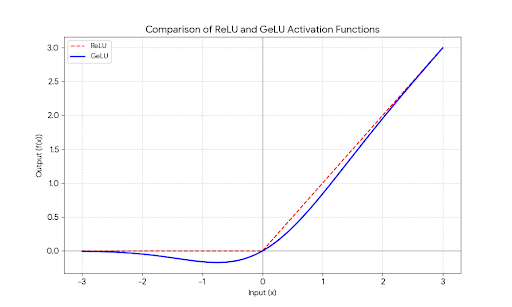

In [108]:
class GELU(nn.Module):

  def __init__(self):
    super().__init__()

  def forward(self, x):
    return 0.5 * x * ( 1 + torch.tanh(
        torch.sqrt(torch.tensor(2.0 / torch.pi)) *
         (x + 0.44715 * torch.pow(x, 3))
    ))

#### ReLU VS GeLU
- ReLU는 양수는 그대로 출력하고, 음수는 모두 0을 출력하는 구간별 선형 함수
- GELU는 부드러운 비선형 함수

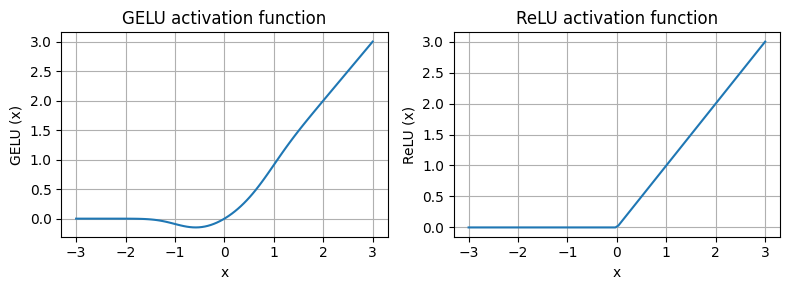

In [109]:
import matplotlib.pyplot as plt

gelu, relu = GELU(), nn.ReLU()

x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)

plt.figure(figsize=(8, 3))

for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
  plt.subplot(1, 2, i)
  plt.plot(x, y)
  plt.title(f"{label} activation function")
  plt.xlabel("x")
  plt.ylabel(f"{label} (x)")
  plt.grid(True)

plt.tight_layout()
plt.show()

In [110]:
class FeedForward(nn.Module):

  def __init__(self, cfg):
    super().__init__()
    self.layers = nn.Sequential(
        # 출력층을 기존 embedding 층의 4배로 늘립
        nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]),
        GELU(),
        # 출력층을 다시 원본 embedding 층의 크기로 만듬
        nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]),
    )

  def forward(self, x):
    return self.layers(x)

In [111]:
ftn = FeedForward(GPT_CONFIG_124M)

x = torch.rand(2,3, 768)
out = ftn(x)
print(out.shape)

torch.Size([2, 3, 768])


# 🔗 숏컷 연결 (Shortcut Connection / Skip Connection)

### 1. 핵심 개념
* **정의:** 특정 층(Layer)의 입력값($x$)을 출력값($F(x)$)에 직접 더해주는 구조
* **별칭:** 잔차 연결(Residual Connection), 스킵 연결(Skip Connection)
* **유래:** 2015년 ResNet(Residual Network) 모델에서 최초 제안
* **철학:** "기존 정보를 보존하면서, 추가로 학습할 '차이(Residual)'만 배우자"

---

### 2. 수학적 표현
$$y = F(x) + x$$
* **$x$:** 입력 데이터 (Identity Mapping, 보존할 정보)
* **$F(x)$:** 가중치 층을 통과한 결과 (Residual, 새로 학습할 정보)
* **$y$:** 최종 출력 (원본 + 변화량)

---

### 3. 도입 목적 및 효과
* **기울기 소실(Vanishing Gradient) 방지:** 역전파 시 숏컷 경로를 통해 기울기가 하위 층으로 손실 없이 전달
* **성능 저하(Degradation) 문제 해결:** 층이 깊어질수록 오차가 커지는 현상을 막아 수천 층까지 설계 가능
* **학습 안정화:** 입력 데이터의 특성이 유지되어 모델 최적화 난이도 하향

---

### 4. LLM (Transformer)에서의 구조적 적용


#### ① 숏컷 연결 1 (Attention 블록)
* **구조:** `입력 x + [LayerNorm -> Masked Multi-Head Attention -> Dropout]`
* **역할:** 문맥 정보를 추출하면서도 단어 고유의 정체성과 위치 정보 보존

#### ② 숏컷 연결 2 (Feed Forward 블록)
* **구조:** `입력 x + [LayerNorm -> Feed Forward -> Dropout]`
* **역할:** 특징 변환 및 차원 확장 과정에서 발생하는 데이터 왜곡 방지

---

### 5. 요약 및 시사점
* **딥러닝의 필수 요소:** 현대 모든 고성능 모델(GPT, Llama, Claude 등)의 표준 아키텍처
* **앙상블 효과:** 여러 경로가 조합되어 다양한 수준의 특징을 동시에 학습하는 효과 발생
* **단순함의 미학:** 파라미터 추가 없이 단순 덧셈만으로 성능 비약적 향상

In [112]:
class ExampleDNN(nn.Module):

  def __init__(self, layer_sizes, use_shortcut) :
    super().__init__()
    self.use_shortcut = use_shortcut
    self.layers = nn.ModuleList(
        [
            nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]), GELU()),
            nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]), GELU())
        ]
    )

  def forward(self, x):
    for layer in self.layers:
      layer_output = layer(x)
      print(x.shape)
      print(layer_output)
      if self.use_shortcut and x.shape == layer_output.shape:
        x = x + layer_output
      else:
        x = layer_output
    return x

def print_gradients(model, x):
  output = model(x)
  target = torch.tensor([0.])

  loss = nn.MSELoss()
  loss = loss(output, target)

  loss.backward()


  for name, param in model.named_parameters():
    if 'weight' in name:
      print(f"{name}의 평균 그레디언트는 {param.grad.abs().mean().item()}입니다.")


In [113]:
torch.manual_seed(123)
layer_sizes = [3, 3, 3, 3, 3, 1]

sample_input = torch.tensor([[1., 0., -1.]])
dnn_without_shortcut = ExampleDNN(layer_sizes, False)

print_gradients(dnn_without_shortcut, sample_input)

torch.Size([1, 3])
tensor([[ 0.1962, -0.1370,  0.0910]], grad_fn=<MulBackward0>)
torch.Size([1, 3])
tensor([[0.0207, 0.1366, 0.3943]], grad_fn=<MulBackward0>)
torch.Size([1, 3])
tensor([[0.0878, 0.2185, 0.0374]], grad_fn=<MulBackward0>)
torch.Size([1, 3])
tensor([[-0.0357, -0.0550,  0.1187]], grad_fn=<MulBackward0>)
torch.Size([1, 3])
tensor([[0.0610]], grad_fn=<MulBackward0>)
layers.0.0.weight의 평균 그레디언트는 0.000204713229322806입니다.
layers.1.0.weight의 평균 그레디언트는 0.00012317953223828226입니다.
layers.2.0.weight의 평균 그레디언트는 0.0007344746263697743입니다.
layers.3.0.weight의 평균 그레디언트는 0.0013871209230273962입니다.
layers.4.0.weight의 평균 그레디언트는 0.005026495084166527입니다.


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


In [114]:
layer_sizes = [3, 3, 3, 3, 3, 1]
torch.manual_seed(123)
sample_input = torch.tensor([[1., 0., -1.]])
dnn_with_shortcut = ExampleDNN(layer_sizes, True)

print_gradients(dnn_with_shortcut, sample_input)

torch.Size([1, 3])
tensor([[ 0.1962, -0.1370,  0.0910]], grad_fn=<MulBackward0>)
torch.Size([1, 3])
tensor([[-0.0961, -0.1029, -0.0010]], grad_fn=<MulBackward0>)
torch.Size([1, 3])
tensor([[0.0785, 1.2755, 0.0972]], grad_fn=<MulBackward0>)
torch.Size([1, 3])
tensor([[-0.1339,  0.0511,  0.4847]], grad_fn=<MulBackward0>)
torch.Size([1, 3])
tensor([[0.8845]], grad_fn=<MulBackward0>)
layers.0.0.weight의 평균 그레디언트는 0.29920274019241333입니다.
layers.1.0.weight의 평균 그레디언트는 0.2749510407447815입니다.
layers.2.0.weight의 평균 그레디언트는 0.454661101102829입니다.
layers.3.0.weight의 평균 그레디언트는 0.3629586696624756입니다.
layers.4.0.weight의 평균 그레디언트는 1.763088583946228입니다.


#### 어텐션 및 선형층 트랜스포머 블록에 연결

In [115]:
!wget https://bit.ly/43BW1j3 -O previous_chapters.py

--2026-02-28 07:33:05--  https://bit.ly/43BW1j3
Resolving bit.ly (bit.ly)... 67.199.248.11, 67.199.248.10
Connecting to bit.ly (bit.ly)|67.199.248.11|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://raw.githubusercontent.com/rickiepark/llm-from-scratch/refs/heads/main/ch04/01_main-chapter-code/previous_chapters.py [following]
--2026-02-28 07:33:06--  https://raw.githubusercontent.com/rickiepark/llm-from-scratch/refs/heads/main/ch04/01_main-chapter-code/previous_chapters.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4199 (4.1K) [text/plain]
Saving to: ‘previous_chapters.py’

previous_chapters.p 100%[===================>]   4.10K  --.-KB/s    in 0s      

2026-02-28 07:33:06 (51.3 MB/s) - ‘previous_chapter

In [116]:
from previous_chapters import MultiHeadAttention


class TransformerBlock(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.att = MultiHeadAttention(
        d_in = cfg["emb_dim"],
        d_out = cfg["emb_dim"],
        context_length=cfg["context_length"],
        num_heads=cfg["n_heads"],
        dropout=cfg["drop_rate"],
        qkv_bias=cfg["qkv_bias"]
    )
    self.ff = FeedForward(cfg)
    self.norm1 = LayerNorm(cfg["emb_dim"])
    self.norm2 = LayerNorm(cfg["emb_dim"])
    self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

  def forward(self, x):

    # 멀티 헤드 어텐션 (단어 간 맥락(관계) 파악)
    shortcut = x
    x = self.norm1(x)
    x = self.att(x)
    x = self.drop_shortcut(x)
    x = x + shortcut

    # 피드 포워드 네트워크
    # 데이터를 늘렸다 줄였다 하면서 각 단어 마다 복잡한 특징을 추출

    shortcut = x
    x = self.norm2(x)
    x = self.ff(x)
    x = self.drop_shortcut(x)
    x = x + shortcut

    return x


In [117]:
torch.manual_seed(123)

x = torch.rand(2, 4, 768)
block = TransformerBlock(GPT_CONFIG_124M)
output = block(x)

print(x.shape)
print(output.shape)


torch.Size([2, 4, 768])
torch.Size([2, 4, 768])


# 🤖 GPT 모델 입출력 및 아키텍처 요약

GPT 모델이 텍스트 입력을 받아 다음 토큰을 예측하기까지의 핵심 연산 흐름

---

### 1️⃣ 입력 처리 및 임베딩 (Input & Embedding)

모델에 들어온 텍스트는 숫자 형태의 고차원 벡터로 변환됨

* **텍스트 토큰화 (Tokenization)**: 문장을 단어 또는 서브워드 단위의 토큰 ID로 분리
* **토큰 임베딩 (Token Embedding)**: 토큰 ID를 고차원 공간의 벡터로 매핑
    * **Shape**: $(50257, 768)$ — *GPT-2 기준 어휘 사전 크기와 임베딩 차원*
* **위치 임베딩 (Positional Embedding)**: 각 토큰에 순서 정보를 부여
* **드롭아웃 (Dropout)**: 학습 시 과적합 방지를 위한 무작위 노드 비활성화

---

### 2️⃣ 트랜스포머 블록 (Transformer Block)

GPT-2 Small 기준, 아래의 구조가 **12번 반복**되어 심층적인 문맥 정보를 추출됨.



| 단계 | 구성 요소 | 역할 및 특징 |
| :--- | :--- | :--- |
| **Step 1** | **층 정규화 1 (Layer Norm)** | 학습의 안정성을 위해 입력값의 평균과 분산을 조정 |
| **Step 2** | **마스크드 멀티헤드 어텐션** | **Masking**을 통해 미래 토큰을 가리고, 과거 토큰들과의 연관성 계산 |
| **Step 3** | **드롭아웃 & 숏컷 연결** | Residual Connection을 통해 원본 정보를 유지하며 기울기 소실 방지 |
| **Step 4** | **층 정규화 2 (Layer Norm)** | 피드 포워드 연산 전 데이터 정규화 |
| **Step 5** | **피드 포워드 (FFN)** | 선형 층과 활성화 함수를 거쳐 토큰의 특징을 비선형적으로 확장 |
| **Step 6** | **드롭아웃 & 숏컷 연결** | 블록의 최종 출력값을 다음 층으로 전달 |

---

### 3️⃣ 최종 출력층 및 행렬 연산 (Output Layer)

압축된 특징 벡터를 다시 단어 확률 분포로 변환하는 단계

#### 🔢 연산 프로세스
1.  **최종 층 정규화 (Final Layer Norm)**: 12개의 블록을 거친 출력값을 최종 정렬
2.  **선형 출력층 (Linear Output Layer)**: 768차원 임베딩을 어휘 사전 크기로 확장

#### 📐 행렬 차원 (Matrix Multiplication)
마지막 선형층에서의 연산

$$(\text{context_length}, 768) \times (768, 50257) = (\text{context_length}, 50257)$$

---

### 🚀 결과 생성 (Generation)
최종 출력된 **Logits** 값에 `Softmax` 함수를 적용하면 다음 토큰이 될 확률 분포가 계산되며, 이 중 가장 적절한 토큰을 선택하여 문장을 이어감

In [118]:
class GPTModel(nn.Module):

  def __init__(self, cfg):
    super().__init__()
    # 어휘사전 크기 X 임베딩 차원
    self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
    # 문맥 크기 X 임베딩 차원
    self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
    self.drop_emb = nn.Dropout(cfg["drop_rate"])

    self.trf_blocks = nn.Sequential(
        *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
    )
    self.final_norm = LayerNorm(cfg["emb_dim"])
    # 임베딩 크기 X 어휘사전 크기 -> (문맥크기 X 임베딩 차원) X (임베딩 차원 X 어휘사전 크기)
    self.out_head = nn.Linear(
        cfg["emb_dim"], cfg["vocab_size"], bias=False
    )

  def forward(self, in_idx):
    in_idx = in_idx.long()
    batch_size, seq_len = in_idx.shape
    tok_embeds = self.tok_emb(in_idx)
    pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device, dtype=torch.long))
    x = tok_embeds + pos_embeds
    x = self.drop_emb(x)
    x = self.trf_blocks(x)
    x = self.final_norm(x)
    logits = self.out_head(x)
    return logits



In [119]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)

out = model(batch)
print(f"입력배치 크기:\n{batch.shape}")
print(f"\n출력 크기:\n{out.shape}")

print(out)

입력배치 크기:
torch.Size([2, 4])

출력 크기:
torch.Size([2, 4, 50257])
tensor([[[ 0.3428,  0.4351, -0.0825,  ...,  0.3370,  0.4601, -0.3005],
         [-0.2209, -0.5443, -0.9922,  ...,  0.0344,  0.5172, -0.3491],
         [ 0.7073,  0.0304,  0.0947,  ...,  0.0531, -0.3858, -0.2466],
         [-1.0247,  0.3700, -0.1148,  ...,  0.7367,  0.3972,  0.0401]],

        [[-0.2840,  0.1041,  0.0137,  ...,  0.2300,  0.4442, -0.7040],
         [ 0.1067,  0.3797, -0.2000,  ...,  0.7599,  0.2686,  0.1849],
         [ 1.0628,  1.0314, -0.2627,  ...,  0.6515,  0.3144, -0.3344],
         [-0.2193,  0.4620,  0.3268,  ...,  1.2306, -0.2181,  0.0456]]],
       grad_fn=<UnsafeViewBackward0>)


#### 총 파라미터 개수
- 1억 2400만 파라미터이어야 함
- 하지만 가중치 묶기에 의해 1억 6300만개

In [120]:
total_params = sum(p.numel() for p in model.parameters())
print(f"총 파라미터 개수: {total_params:,}")

총 파라미터 개수: 163,009,536


#### 텍스트 생성하기

GPT 모델의 토큰 생성 과정

1) 텍스트 입력을 토큰 ID로 인코딩
2) GPT 모델은 N개의 행과 50257 열로 구성된 행렬을 반환
3) GPT 모델이 생성할 다음 토큰에 해당하는 마지막 벡터 추출
4) 소프트맥스 함수를 사용하여 로짓을 확률분포로 변환
5) 가장 큰 값의 인덱스 위치(토큰 ID)로 찾음
6) 다음 라운드를 위해 이 토큰을 이전 입력에 추가
7) 위의 작업 반복

#### 그리디 디코딩
- 각 단계마다 가장 높은 확률을 가진 단어를 다음 출력으로 선택
- 소프트맥스 함수를 적용할 필요 없음
- 하지만 문맥이 자연스럽지 못하다는 단점 존재

In [121]:
def generate_text_simple(model, idx, max_new_tokens, context_size):
  # idx: 현재 문맥에 담긴 (batch, n_tokens) 배열
  for _ in range(max_new_tokens):

    # 현재 문맥에 모델이 지원하는 문맥크기를 초과하면 잘라냄
    idx_cond = idx[:, -context_size: ]

    with torch.no_grad():
      logits = model(idx_cond)

    # 마지막 스텝만 사용
    # (batch, n_token, vocab_size) -> (batch, vocab_size)
    logits = logits[:, -1, :]

    # 확률을 얻기 위해 소프트맥스를 적용
    probas = torch.softmax(logits, dim=-1) # 행 기준으로 소프트맥스

    # 가장 높은 확률 값을 가진 항목의 인덱스를 얻음
    idx_next = torch.argmax(probas, dim=-1, keepdim=True) # (batch, 1)

    # 선택한 인덱스를 현재 시퀀스에 추가
    idx = torch.cat((idx, idx_next), dim=1) # (batch, n_tokens + 1)

  return idx





In [122]:
start_context = "Hello, I am"

encoded = tokenizer.encode(start_context)
print("인코딩된 ID: ", encoded)

encoded_tensor = torch.tensor(encoded).unsqueeze(0)
print("encoded_tensor.shape", encoded_tensor.shape)

인코딩된 ID:  [15496, 11, 314, 716]
encoded_tensor.shape torch.Size([1, 4])


In [123]:
model.eval()

out = generate_text_simple(
    model=model,
    idx=encoded_tensor,
    max_new_tokens=6,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("출력: ", out)
print("출력 길이: ", len(out[0]))

출력:  tensor([[15496,    11,   314,   716, 27018, 24086, 47843, 30961, 29739,   554]])
출력 길이:  10


In [124]:
decoded_text = tokenizer.decode(out.squeeze(0).tolist())
print(decoded_text)

Hello, I am Featureiman Byeswick Exit In


#### 4장 연습문제

In [125]:
!wget https://bit.ly/3SZbhlj -O gpt.py

--2026-02-28 07:33:09--  https://bit.ly/3SZbhlj
Resolving bit.ly (bit.ly)... 67.199.248.11, 67.199.248.10
Connecting to bit.ly (bit.ly)|67.199.248.11|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://raw.githubusercontent.com/rickiepark/llm-from-scratch/refs/heads/main/ch04/01_main-chapter-code/gpt.py [following]
--2026-02-28 07:33:09--  https://raw.githubusercontent.com/rickiepark/llm-from-scratch/refs/heads/main/ch04/01_main-chapter-code/gpt.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9675 (9.4K) [text/plain]
Saving to: ‘gpt.py’

gpt.py              100%[===================>]   9.45K  --.-KB/s    in 0s      

2026-02-28 07:33:09 (122 MB/s) - ‘gpt.py’ saved [9675/9675]



#### 4.1 피드포워드 신경망과 어텐션 모듈의 파라미터 수
- 피드포워드, 어텐션 모듈 X 12 = 1억 2,400만

In [126]:
from gpt import TransformerBlock

GPT_CONFIG_124M = {
    "vocab_size": 50257, # 어휘사전 크기
    "context_length": 1024, # 입력 토큰의 최대 개수
    "emb_dim": 768, # 임베딩 크기
    "n_heads": 12, # 멀티 헤드 개수 -> 즉, 각 헤드에서는 64 차원
    "n_layers": 12, # 층 개수
    "drop_rate": 0.1, # 드롭아웃 비율
    "qkv_bias": False # 쿼리, 키, 값 생성 시 편향 포함 여부
}

In [127]:
block = TransformerBlock(GPT_CONFIG_124M)
print(block)

TransformerBlock(
  (att): MultiHeadAttention(
    (W_query): Linear(in_features=768, out_features=768, bias=False)
    (W_key): Linear(in_features=768, out_features=768, bias=False)
    (W_value): Linear(in_features=768, out_features=768, bias=False)
    (out_proj): Linear(in_features=768, out_features=768, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (ff): FeedForward(
    (layers): Sequential(
      (0): Linear(in_features=768, out_features=3072, bias=True)
      (1): GELU()
      (2): Linear(in_features=3072, out_features=768, bias=True)
    )
  )
  (norm1): LayerNorm()
  (norm2): LayerNorm()
  (drop_shortcut): Dropout(p=0.1, inplace=False)
)


In [128]:
total_params = sum(p.numel() for p in block.ff.parameters())
print(f"피드 포워드 모듈 총 파라미터 수: {total_params:,}")

피드 포워드 모듈 총 파라미터 수: 4,722,432


In [129]:
total_params = sum(p.numel() for p in block.att.parameters())
print(f"어텐션 모듈 총 파라미터 수: {total_params:,}")

어텐션 모듈 총 파라미터 수: 2,360,064


In [130]:
# 더 큰 GPT 모델로 초기화

GPT_CONFIG_124M = {
    "vocab_size": 50257, # 어휘사전 크기
    "context_length": 1024, # 입력 토큰의 최대 개수
    "emb_dim": 768, # 임베딩 크기
    "n_heads": 12, # 멀티 헤드 개수 -> 즉, 각 헤드에서는 64 차원
    "n_layers": 12, # 층 개수
    "drop_rate": 0.1, # 드롭아웃 비율
    "qkv_bias": False # 쿼리, 키, 값 생성 시 편향 포함 여부
}

def get_config(base_config, model_name="gpt2-small"):
  GPT_CONFIG = base_config.copy()

  if model_name == "gpt2-small":
    GPT_CONFIG["emb_dim"] = 768
    GPT_CONFIG["n_layers"] = 12
    GPT_CONFIG["n_heads"] = 12

  elif model_name == "gpt2-medium":
    GPT_CONFIG["emb_dim"] = 1024
    GPT_CONFIG["n_layers"] = 24
    GPT_CONFIG["n_heads"] = 16

  elif model_name == "gpt2-large":
    GPT_CONFIG["emb_dim"] = 1280
    GPT_CONFIG["n_layers"] = 36
    GPT_CONFIG["n_heads"] = 20

  elif model_name == "gpt2-xl":
    GPT_CONFIG["emb_dim"] = 1600
    GPT_CONFIG["n_layers"] = 48
    GPT_CONFIG["n_heads"] = 25

  else:
    raise ValueError(f"잘못된 모델 이름: {model_name}")

  return GPT_CONFIG


def calculate_size(model):
  total_params = sum(p.numel() for p in model.parameters())
  print(f"전체 파라미터 수: {total_params:,}")

  total_params_gpt2 = total_params - sum(p.numel() for p in model.out_head.parameters())
  print(f"가중치 묶기를 고려한 훈련 가능한 파라미터 수: {total_params_gpt2:,}")

  total_size_bytes = total_params * 4

  total_size_mb = total_size_bytes  / (1024 * 1024)

  print(f"모델의 총 크기: {total_size_mb:.2f} MB")


In [131]:
from gpt import GPTModel

for model_abbrev in ("small", "medium", "large", "xl"):
  model_name = f"gpt2-{model_abbrev}"
  CONFIG = get_config(GPT_CONFIG_124M, model_name=model_name)
  model = GPTModel(CONFIG)
  print(f"\n\n{model_name}:")
  calculate_size(model)



gpt2-small:
전체 파라미터 수: 163,009,536
가중치 묶기를 고려한 훈련 가능한 파라미터 수: 124,412,160
모델의 총 크기: 621.83 MB


gpt2-medium:
전체 파라미터 수: 406,212,608
가중치 묶기를 고려한 훈련 가능한 파라미터 수: 354,749,440
모델의 총 크기: 1549.58 MB


gpt2-large:
전체 파라미터 수: 838,220,800
가중치 묶기를 고려한 훈련 가능한 파라미터 수: 773,891,840
모델의 총 크기: 3197.56 MB


gpt2-xl:
전체 파라미터 수: 1,637,792,000
가중치 묶기를 고려한 훈련 가능한 파라미터 수: 1,557,380,800
모델의 총 크기: 6247.68 MB


# 🤖 GPT 사전 훈련 및 텍스트 생성 매커니즘

## 1. GPT 기반 텍스트 생성 (Text Generation)
레이블이 없는 데이터를 활용하여 다음 토큰을 예측하는 자기 회귀 모델의 생성 과정

* **입력 텍스트 인코딩**: 토크나이저를 활용한 입력 텍스트의 토큰 ID 변환
* **로짓(Logits) 생성**: GPT 모델 통과 및 각 토큰별 어휘 사전 크기의 벡터 산출
* **텍스트 디코딩**: 로짓의 토큰 ID 변환 및 토크나이저를 통한 최종 텍스트 복원



---

## 2. 손실 함수 계산 (Cross-Entropy Loss)
모델의 예측값과 실제 타깃 사이의 오차를 수치화하는 과정

1. **확률 변환**: 소프트맥스(Softmax) 함수를 통한 로짓의 확률 분포화
2. **타깃 확률 추출**: 산출된 확률 분포 중 실제 정답(Next Token)의 확률값 선택
3. **로그 변환**: 수치적 안정성을 위한 추출 확률의 로그값($\log$) 취득
4. **평균 산출**: 시퀀스 전체 토큰에 대한 로그 확률의 평균 계산
5. **최종 손실 산출**: 학습 최적화를 위한 음의 평균 로그 확률(NLL) 적용
   $$Loss = -\frac{1}{N} \sum_{i=1}^{N} \log(P_i)$$



---

## 3. 데이터셋 준비 및 배치 구성 (Data Pipeline)
효율적인 학습을 위한 데이터의 전처리 및 구조화

* **데이터셋 분할**: 모델 학습용(Train) 대량 데이터와 성능 평가용(Validation) 소량 데이터의 분리
* **토큰화 및 샘플링**: 전체 데이터셋의 토큰화 수행 및 일정한 길이(Context Window)의 샘플 분할
* **배치(Batch) 구성**: 병렬 연산 및 학습 속도 향상을 위한 다수 샘플의 그룹화
* **입력-타깃 설정**: 한 토큰씩 밀린(Shifted) 구조의 데이터 구성 (Next-Token Prediction 목적)

---
> **💡 참고**: GPT 모델은 별도의 정답 레이블 없이 텍스트 자체를 정답으로 사용하는 **자기 지도 학습(Self-Supervised Learning)** 방식을 따름.

#### 레이블이 없는 데이터 사전 훈련에 활용

In [1]:
!wget https://bit.ly/3HlFmc8 -O previous_chapters.py

--2026-02-28 07:34:40--  https://bit.ly/3HlFmc8
Resolving bit.ly (bit.ly)... 67.199.248.11, 67.199.248.10
Connecting to bit.ly (bit.ly)|67.199.248.11|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://raw.githubusercontent.com/rickiepark/llm-from-scratch/refs/heads/main/ch05/01_main-chapter-code/previous_chapters.py [following]
--2026-02-28 07:34:40--  https://raw.githubusercontent.com/rickiepark/llm-from-scratch/refs/heads/main/ch05/01_main-chapter-code/previous_chapters.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 9905 (9.7K) [text/plain]
Saving to: ‘previous_chapters.py’

previous_chapters.p 100%[===================>]   9.67K  --.-KB/s    in 0s      

2026-02-28 07:34:40 (108 MB/s) - ‘previous_chapters

In [2]:
from previous_chapters import GPTModel
import torch


GPT_CONFIG_124M = {
    "vocab_size": 50257, # 어휘사전 크기
    "context_length": 256, # 입력 토큰의 최대 개수 -> 원래는 102개
    "emb_dim": 768, # 임베딩 크기
    "n_heads": 12, # 멀티 헤드 개수 -> 즉, 각 헤드에서는 64 차원
    "n_layers": 12, # 층 개수
    "drop_rate": 0.1, # 드롭아웃 비율
    "qkv_bias": False # 쿼리, 키, 값 생성 시 편향 포함 여부
}

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval() # 추론 시 Dropout 비활성화

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

- 최근 모델에서는 Dropout을 사용하지 않고 LLM을 훈련하는 경우가 많음
- 최신 LLM은 쿼리, 키, 값 행렬을 위한 nn.Linear 층에서 편향 벡터 사용을 하지 않음
- 사전 훈련 전이라 좋은 텍스트가 생성되지 않음
- 이러한 성능을 정량적인 성능으로 측정할 지표가 필요함

In [3]:
import tiktoken
from previous_chapters import generate_text_simple

def text_to_token_ids(text, tokenizer):
  encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
  encoded_tensor = torch.tensor(encoded).unsqueeze(0) # 배치차원 추가 (신경망 모델은 첫번째 위치에 배치가 항상 존재)
  return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
  flat = token_ids.squeeze(0) # 배치차원 제거
  return tokenizer.decode(flat.tolist())


start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M['context_length']
)

print(f"출력 텍스트:\n{token_ids_to_text(token_ids, tokenizer)}")

출력 텍스트:
Every effort moves you rentingetic wasnم refres RexMeCHicular stren


#### 텍스트 생성 손실 계산: 크로스 엔트로피 & 혼잡도
- targets의 경우 inputs에서 한 토큰 씩 이동한 형태

In [4]:
inputs = torch.tensor(
    [[16833, 3626, 6100],
     [40, 1107, 588]
     ]
)

targets = torch.tensor([
    [3626, 6100, 345],
    [1107, 588, 11311]
])

In [5]:
with torch.no_grad():
  logits = model(inputs)

probas = torch.softmax(logits, dim=-1)
print(probas.shape) # (batch_size, num_tokens, vocab_size)

torch.Size([2, 3, 50257])


In [6]:
token_ids = torch.argmax(probas, dim=-1, keepdim=True)
print("토큰 ID:\n", token_ids)

토큰 ID:
 tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])


In [7]:
print(token_ids_to_text(targets[0], tokenizer)) # 실제 타겟
print(token_ids_to_text(token_ids[0].flatten(), tokenizer)) # 실제 생성된 텍스트


 effort moves you
 Armed heNetflix


In [8]:
text_idx = 0
target_probas_1 = probas[text_idx, [0, 1, 2], targets[text_idx]] # (첫번째 배치, 3개의 토큰, 각 타겟인덱스)
print(f"텍스트 1: {target_probas_1}")

text_idx = 1
target_probas_2 = probas[text_idx, [0, 1, 2], targets[text_idx]]
print(f"텍스트 1: {target_probas_2}")

텍스트 1: tensor([7.4540e-05, 3.1061e-05, 1.1563e-05])
텍스트 1: tensor([1.0337e-05, 5.6776e-05, 4.7559e-06])


In [9]:
log_probas = torch.log(torch.cat((target_probas_1, target_probas_2)))
print(log_probas)

tensor([ -9.5042, -10.3796, -11.3677, -11.4798,  -9.7764, -12.2561])


In [10]:
# 로그 확률의 평균
avg_log_probas = torch.mean(log_probas)
print(avg_log_probas)

tensor(-10.7940)


In [11]:
neg_avg_log_probas = avg_log_probas * -1
print(neg_avg_log_probas)

tensor(10.7940)


#### 크로스 엔트로피 함수 사용 전, 로짓 크기 및 타깃의 크기 확인

In [12]:
print(f"로짓 크기: {logits.shape}")
print(f"타겟 크기: {targets.shape}")

로짓 크기: torch.Size([2, 3, 50257])
타겟 크기: torch.Size([2, 3])


In [13]:
# 배치차원 삭제

logits_flat = logits.flatten(0, 1)
targets_flat = targets.flatten()

print(f"펼친 로짓 크기: {logits_flat.shape}")
print(f"펼친 타겟 크기: {targets_flat.shape}")


펼친 로짓 크기: torch.Size([6, 50257])
펼친 타겟 크기: torch.Size([6])


#### 타깃은 토큰 ID이며, 로짓 텐서의 인덱스를 나타냄
#### 파이토치의 cross_entropy는 최대화활 토큰 인덱스에 대해 자동으로 소프트맥스와 로그 확률 계산을 수행

In [14]:
loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
print(loss)

tensor(10.7940)


In [15]:
perplexity = torch.exp(loss)
print(perplexity)

tensor(48725.8203)


#### 훈련세트와 검증 세트의 손실 계산

In [16]:
import os
import urllib.request

if not os.path.exists("the-verdict.txt"):
    url = (
        "https://raw.githubusercontent.com/rasbt/"
        "LLMs-from-scratch/main/ch02/01_main-chapter-code/"
        "the-verdict.txt"
    )
    file_path = "the-verdict.txt"
    urllib.request.urlretrieve(url, file_path)

In [17]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
 text_data = f.read()

In [18]:
print(text_data[:99])

I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 


In [19]:
print(text_data[-99:])

it for me! The Strouds stand alone, and happen once--but there's no exterminating our kind of art."


In [20]:
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))

print(f"문자: {total_characters}")
print(f"토큰: {total_tokens}")

문자: 20479
토큰: 5145


In [21]:
from previous_chapters import create_dataloader_v1

train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=True,
    num_workers=0
)

In [22]:
print(f"훈련 데이터 로더:")
for x, y in train_loader:
  print(x.shape, y.shape)


print(f"검증 데이터 로더:")
for x, y in val_loader:
  print(x.shape, y.shape)

훈련 데이터 로더:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
검증 데이터 로더:
torch.Size([2, 256]) torch.Size([2, 256])


In [23]:
def calc_loss_batch(input_batch, target_batch, model, device):
  input_batch, target_batch = input_batch.to(device), target_batch.to(device)
  logits = model(input_batch)
  loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
  return loss


def calc_loss_loader(data_loader, model, device, num_batches=None):
  total_loss = 0

  if len(data_loader) == 0 :
    return float("nan")
  elif num_batches is None:
    num_batches = len(data_loader)
  else:
    num_batches = min(num_batches, len(data_loader))
  for i, (input_batch, target_batch) in enumerate(data_loader):
    if i < num_batches:
      loss = calc_loss_batch(input_batch, target_batch, model, device)
      total_loss += loss.item()
    else:
      break
  return total_loss / num_batches


In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)
torch.manual_seed(123)
with torch.no_grad():
  train_loss = calc_loss_loader(train_loader, model, device)
  val_loss = calc_loss_loader(val_loader, model, device)

print(f"훈련 손실: {train_loss}")
print(f"검증 손실: {val_loss}")

훈련 손실: 10.987583266364204
검증 손실: 10.98110580444336


#### LLM 훈련하기

- 파이토치의 일반적인 훈련 루프
1) 훈련 에포크마다 배치를 순회
2) 이전 배치 반복에서 얻은 그레디언트를 초기화
3) 현재 배치의 손실 계산
4) 역전파를 통해 손실에 기여하는 그레디언트 계산
5) 손실 그레디언트를 사용하여 모델 가중치 업데이트
6) 훈련 세트 손실과 검증 세트 손실 출력 (훈련 과정 추적하기 위한 추가 단계1)
7) 시각적인 통찰을 위해 샘플 텍스트를 생성 (훈련 과정 추적하기 위한 추가 단계2)
8) 위의 1 ~ 7의 과정을 통해 훈련 에포크를 반복

In [25]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs, eval_freq, eval_iter, start_context, tokenizer):

  # 손실 및 토큰 수 추적
  train_losses, val_losses, track_tokens_seen = [], [], []
  tokens_seen, global_step = 0, -1
  # 에포크별 실행
  for epoch in range(num_epochs):
    model.train()
    # 배치별 실행
    for input_batch, target_batch in train_loader:
      optimizer.zero_grad() # 이전 배치에서 얻은 손실의 그레디언트 초기화
      loss = calc_loss_batch(input_batch, target_batch, model, device) # 손실 계산
      loss.backward() # 손실 그레디언트 계산

      optimizer.step() # 모델 가중치 업데이트
      tokens_seen += input_batch.numel()
      global_step += 1

      # 추가 평가
      if global_step % eval_freq == 0:
        train_loss, val_loss = evaluate_model(model, train_loader, val_loader, device, eval_iter)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        track_tokens_seen.append(tokens_seen)
        print(f"에포크 {epoch + 1} (Step {global_step:06d}):  "
              f"훈련 손실 {train_loss:.3f}, 검증손실: {val_loss:.3f}")

    generate_and_print_sample(model, tokenizer, device, start_context)

  return train_losses, val_losses, track_tokens_seen

def evaluate_model(model, train_loader, val_loader, device, eval_iter):
  model.eval()
  with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
  model.train()
  return train_loss, val_loss

def generate_and_print_sample(model, tokenizer, device, start_context):
  model.eval()
  context_size = model.pos_emb.weight.shape[0]
  encoded = text_to_token_ids(start_context, tokenizer).to(device)
  with torch.no_grad():
    token_ids = generate_text_simple(model=model, idx=encoded, max_new_tokens=50, context_size=context_size)

  decoded_text = token_ids_to_text(token_ids, tokenizer)
  print(decoded_text.replace("\n", " "))
  model.train()


In [26]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
    )



에포크 1 (Step 000000):  훈련 손실 9.818, 검증손실: 9.930
에포크 1 (Step 000005):  훈련 손실 7.920, 검증손실: 8.336
Every effort moves you,,,,,,,,,,,,.                                     
에포크 2 (Step 000010):  훈련 손실 6.585, 검증손실: 7.046
에포크 2 (Step 000015):  훈련 손실 5.984, 검증손실: 6.598
Every effort moves you, the, and, the, the, the, and, the. ", the,,, the, and, the,, the,, the, and, the, the,, the, and,,,,, the
에포크 3 (Step 000020):  훈련 손실 15.871, 검증손실: 15.947
에포크 3 (Step 000025):  훈련 손실 5.578, 검증손실: 6.453
Every effort moves you. Gis. Gis. Gis. Gis. G. I had to----, and--. I had to--. I had. I had to the his--. I had the to the ", and I had.
에포크 4 (Step 000030):  훈련 손실 5.009, 검증손실: 6.335
에포크 4 (Step 000035):  훈련 손실 4.767, 검증손실: 6.249
Every effort moves you, and I had been the, I had to the picture. ", I had been--I, I had been the to the of the, I had the to the, I had been, I had the picture. ", I
에포크 5 (Step 000040):  훈련 손실 4.222, 검증손실: 6.236
Every effort moves you know one of his pictures--I was his picture

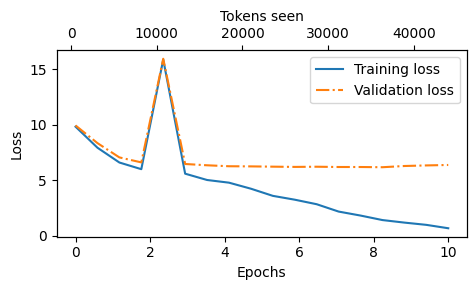

In [27]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # 에포크에 대한 훈련 손실과 검증 손실의 그래프를 그립니다.
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # only show integer labels on x-axis

    # 처리한 토큰 수에 대한 두 번째 x 축을 만듭니다.
    ax2 = ax1.twiny()  # y 축을 공유하는 두 번째 x 축을 만듭니다.
    ax2.plot(tokens_seen, train_losses, alpha=0)  # 눈금을 정렬하기 위해 투명한 그래프를 만듭니다.
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()
    plt.savefig("loss-plot.pdf")
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

#### 무작위성 제어를 위한 디코딩 전략
- 앞선 디코딩 전략은 그리드 디코딩 (가장 확률이 높은 토큰을 그 다음 텍스트로 선택)

- 온도 스케일링
  - 온도($T$)는 모델이 출력하는 확률 분포의 **부드러움**을 조절하는 하이퍼파라미터.
  - 모델 내부의 로짓(Logits) 값을 소프트맥스(Softmax) 함수에 넣기 전에 $T$로 나누어 계산
  - T가 낮을 때: 결과가 매우 결정론적으로 나옴 (확률이 높은 값 위주로 선택)
  - T가 높을 때:
    - 확률 분포를 평평하게 만듬, 더 창의적이고 다양한 텍스트 선택 가능
    - 그러나 맥락 없는 말을 생성할 가능성도 존재

- Top-K Sampling
  - 확률이 가장 높은 상위 K개의 단어 후보만 남기고 나머지는 후보에서 완전히 제외하는 방식
  - Top-K를 제외하고 나머지 값 음의 무한대 값으로 치환
  - 소프트맥스 함수를 거치면 음의 무한대 값은 0으로 나머지 값은 총합이 1인 확률이 됨
  - K값이 고정되어 있다는 단점을 해결하기 위해, 누적확률을 사용하는 Top-P Sampling도 존재



#### 그리디 디코딩 전략
- 함수를 여러번 실행하더라도 항상 동일한 출력 생성

In [28]:
model.to("cpu")
model.eval()

tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("출력 텍스트: \n", token_ids_to_text(token_ids, tokenizer))

출력 텍스트: 
 Every effort moves you?"

"Yes--quite insensible to the irony. She wanted him vindicated--and by me!"




#### 온도 스케일링
- torch.multinomial(probs, num_samples) 를 사용하여 토큰 샘플링

In [29]:
vocab = {
    "closer": 0,
    "every": 1,
    "effort": 2,
    "forward": 3,
    "inches": 4,
    "moves": 5,
    "pizza": 6,
    "toward": 7,
    "you": 8,
}

inverse_vocab = {v: k for k, v in vocab.items()}

next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)
# 3번 인덱스가 가장 커서 추출됨
probas = torch.softmax(next_token_logits, dim=0)
print(probas)
next_token_id = torch.argmax(probas).item()

print(inverse_vocab[next_token_id])



tensor([6.0907e-02, 1.6313e-03, 1.0019e-04, 5.7212e-01, 3.4190e-03, 1.3257e-04,
        1.0120e-04, 3.5758e-01, 4.0122e-03])
forward


In [30]:
torch.manual_seed(123)
next_token_id = torch.multinomial(probas, num_samples=1).item()
print(inverse_vocab[next_token_id])

forward


#### multinomial()을 통해 소프트맥스 분포에서 1000번 토큰 샘플링

In [31]:
def print_sampled_tokens(probas):
  torch.manual_seed(123)
  sample = [torch.multinomial(probas, num_samples=1).item() for i in range(1000)]
  # print(sample)
  sampled_ids = torch.bincount(torch.tensor(sample), minlength=len(probas))
  # print(sampled_ids)
  for i, freq in enumerate(sampled_ids):
    print(f"{freq} X {inverse_vocab[i]}")

print_sampled_tokens(probas)

73 X closer
0 X every
0 X effort
582 X forward
2 X inches
0 X moves
0 X pizza
343 X toward
0 X you


#### 온도 스케일링 분포와 선택 과정 조절
- 로짓을 0 보다 큰 숫자로 나누는 것
- 1보다 큰 온도는 소프트맥스 함수를 적용한 후에 더욱 균등한 확률 분포를 만듬
- 1보다 작은 온도는 소프트맥스 함수를 적용한 후에 더 결정론적인 분포를 만듬

In [32]:
def softmax_with_temperature(logits, temperature):
  scaled_logits = logits / temperature
  return torch.softmax(scaled_logits, dim= 0)

temperatures = [1, 0.1, 5]
scaled_probas = [softmax_with_temperature(next_token_logits, T) for T in temperatures]

#### 온도 0.1 스케일링

In [33]:
print_sampled_tokens(scaled_probas[1])


0 X closer
0 X every
0 X effort
985 X forward
0 X inches
0 X moves
0 X pizza
15 X toward
0 X you


#### 온도 5 스케일링

In [34]:
print_sampled_tokens(scaled_probas[2])

165 X closer
75 X every
42 X effort
239 X forward
71 X inches
46 X moves
32 X pizza
227 X toward
103 X you


In [35]:
print_sampled_tokens(scaled_probas[0])

73 X closer
0 X every
0 X effort
582 X forward
2 X inches
0 X moves
0 X pizza
343 X toward
0 X you


#### Top-K 샘플링

In [36]:
top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k)

print("탑-k 로짓: ", top_logits)
print("탑-k 위치: ", top_pos)

탑-k 로짓:  tensor([6.7500, 6.2800, 4.5100])
탑-k 위치:  tensor([3, 7, 0])


In [37]:
new_logits = torch.where(
    condition=next_token_logits < top_logits[-1],
    input=torch.tensor(float("-inf")),
    other=next_token_logits
)
print(new_logits)

tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])


In [38]:
topk_probas = torch.softmax(new_logits, dim=0)
print(topk_probas)

tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


In [39]:
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):

    # for 루프는 이전과 동일. 로짓을 받아 마지막 타임 스텝만 사용
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]

        # 탑-k 샘플링으로 로짓을 필터링
        if top_k is not None:
            # 탑-k 값만 유지합니다.
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(logits < min_val, torch.tensor(float("-inf")).to(logits.device), logits)

        # 온도 스케일링을 적용합니다.
        if temperature > 0.0:
            logits = logits / temperature

            # (책에 없음): mps 장치에서 동일한 결과를 얻기 위해 수치 안정성을 위한 팁
            # 소프트맥스 전에 행의 최댓값을 뺌
            logits = logits - logits.max(dim=-1, keepdim=True).values

            # 소프트맥스 함수를 적용하여 확률을 얻음
            probs = torch.softmax(logits, dim=-1)  # (batch_size, context_len)

            # 분포에서 샘플링.
            idx_next = torch.multinomial(probs, num_samples=1)  # (batch_size, 1)

        # 온도 스케일링을 사용하지 않는 경우 이전처럼 그리디 샘플링을 사용해 다음 토큰을 선택.
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)  # (batch_size, 1)

        if idx_next == eos_id:  # eos_id가 지정되어 있고 EoS 토큰을 만나면 생성을 중단.
            break

        # 이전과 동일하게 샘플링된 인덱스를 현재 시퀀스 뒤에 추가.
        idx = torch.cat((idx, idx_next), dim=1)  # (batch_size, num_tokens+1)

    return idx

#### 파이토치 모델 로드 및 저장
- torch.save 함수를 state_dict() 메서드 결과에 적용하여 모델의 가중치를 저장하는 것이 권장


In [40]:
torch.save(model.state_dict(), "model.pth")

In [41]:
model = GPTModel(GPT_CONFIG_124M)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.load_state_dict(torch.load("model.pth", map_location=device, weights_only=True))
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

- Adam, AdamW와 같은 적응형 옵티마이저의 경우 LLM으로 훈련
- 모델 가중치마다 추가적인 파라미터를 저장하고 있기 때문에 해당 파라미터도 저장이 필요

In [42]:
torch.save({
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
},
    "model_and_optimizer.pth")

In [43]:
checkpoint = torch.load("model_and_optimizer.pth", weights_only=True)

model = GPTModel(GPT_CONFIG_124M)
model.load_state_dict(checkpoint["model_state_dict"])

optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005, weight_decay=0.1)
optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

In [44]:
model.train()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [ ]:
import os
import urllib.request

file_name = "gpt2-small-124M.pth"

url = f"https://huggingface.co/rasbt/gpt2-from-scratch-pytorch/resolve/main/{file_name}"


if not os.path.exists(file_name):
  urllib.request.urlretrieve(url, file_name)
  print(f"다운로드 파일: {file_name}")


gpt = GPTModel(BASE_CONFIG)
gpt.load_state_dict(torch.load(file_name, weights_only=True))
gpt.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
gpt.to(device)

torch.manual_seed(123)

token_ids = generate(modiel=gpt,
                     idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
                     max_new_tokens=25,
                     context_size=NEW_CONFIG["context_length"],
                     top_k=50,
                     temperature=1.5
                     )

print("출력 텍스트:\n", token_ids_to_text(token_ids, tokenizer))

In [50]:
!wget https://bit.ly/4kSEn1v -O gpt_download.py

--2026-02-28 07:44:16--  https://bit.ly/4kSEn1v
Resolving bit.ly (bit.ly)... 67.199.248.11, 67.199.248.10
Connecting to bit.ly (bit.ly)|67.199.248.11|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://raw.githubusercontent.com/rickiepark/llm-from-scratch/refs/heads/main/ch05/01_main-chapter-code/gpt_download.py [following]
--2026-02-28 07:44:17--  https://raw.githubusercontent.com/rickiepark/llm-from-scratch/refs/heads/main/ch05/01_main-chapter-code/gpt_download.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5972 (5.8K) [text/plain]
Saving to: ‘gpt_download.py’

gpt_download.py     100%[===================>]   5.83K  --.-KB/s    in 0s      

2026-02-28 07:44:17 (30.6 MB/s) - ‘gpt_download.py’ saved [5972/59

In [51]:
from gpt_download import download_and_load_gpt2

In [52]:
settings, params = download_and_load_gpt2(model_size="124M", models_dir="gpt2")


checkpoint: 100%|██████████| 77.0/77.0 [00:00<00:00, 191kiB/s]
encoder.json: 100%|██████████| 1.04M/1.04M [00:00<00:00, 2.62MiB/s]
hparams.json: 100%|██████████| 90.0/90.0 [00:00<00:00, 174kiB/s]
model.ckpt.data-00000-of-00001: 100%|██████████| 498M/498M [00:38<00:00, 12.8MiB/s]
model.ckpt.index: 100%|██████████| 5.21k/5.21k [00:00<00:00, 8.72MiB/s]
model.ckpt.meta: 100%|██████████| 471k/471k [00:00<00:00, 1.63MiB/s]
vocab.bpe: 100%|██████████| 456k/456k [00:00<00:00, 1.91MiB/s]


### 설정 파라미터
- n_vocab: 어휘사전
- n_ctx: 문맥크기
- n_embd: 임베딩 크기
- n_head: 헤드 개수
- n_layer: 층 개수

In [53]:
print("설정", settings)

설정 {'n_vocab': 50257, 'n_ctx': 1024, 'n_embd': 768, 'n_head': 12, 'n_layer': 12}


In [54]:
print("파라미터 키", params.keys())

파라미터 키 dict_keys(['blocks', 'b', 'g', 'wpe', 'wte'])


In [55]:
print(params["wte"])
print("토큰 임베딩 가중치 텐서 차원", params["wte"].shape)

[[-0.11010301 -0.03926672  0.03310751 ... -0.1363697   0.01506208
   0.04531523]
 [ 0.04034033 -0.04861503  0.04624869 ...  0.08605453  0.00253983
   0.04318958]
 [-0.12746179  0.04793796  0.18410145 ...  0.08991534 -0.12972379
  -0.08785918]
 ...
 [-0.04453601 -0.05483596  0.01225674 ...  0.10435229  0.09783269
  -0.06952604]
 [ 0.1860082   0.01665728  0.04611587 ... -0.09625227  0.07847701
  -0.02245961]
 [ 0.05135201 -0.02768905  0.0499369  ...  0.00704835  0.15519823
   0.12067825]]
토큰 임베딩 가중치 텐서 차원 (50257, 768)


- 위에서 로드한 1억 2400만 파라미터를 GPTModel 클래스 인스턴스로 복사하는 작업 진행
- GPTModel 초기화
- 원본의 경우 쿼리, 키, 값 행렬을 위한 선형층에서 편향 벡터 사용
- 원본의 경우 GPT2 모델에서 사용한 문맥 크기 1024 사용

In [56]:
model_configs = {
            "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
            "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
            "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
            "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
        }

model_name = "gpt2-small (124M)"
NEW_CONFIG= GPT_CONFIG_124M.copy()
NEW_CONFIG.update(model_configs[model_name])
NEW_CONFIG.update({"context_length": 1024, "qkv_bias": True})

gpt = GPTModel(NEW_CONFIG)
gpt.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

- OpenAI 가중치를 GPTModel 인스턴스에 있는 가중치 텐선에 할당

In [58]:
import numpy as np

def assign(left, right):
  if left.shape != right.shape:
    raise ValueError(f"크기가 다릅니다. left: {left.shape}, right: {right.shape}")
  return torch.nn.Parameter(torch.tensor(right))

def load_weights_into_gpt(gpt, params):
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])

    for b in range(len(params["blocks"])):
        q_w, k_w, v_w = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["w"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.weight = assign(
            gpt.trf_blocks[b].att.W_query.weight, q_w.T)
        gpt.trf_blocks[b].att.W_key.weight = assign(
            gpt.trf_blocks[b].att.W_key.weight, k_w.T)
        gpt.trf_blocks[b].att.W_value.weight = assign(
            gpt.trf_blocks[b].att.W_value.weight, v_w.T)

        q_b, k_b, v_b = np.split(
            (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
        gpt.trf_blocks[b].att.W_query.bias = assign(
            gpt.trf_blocks[b].att.W_query.bias, q_b)
        gpt.trf_blocks[b].att.W_key.bias = assign(
            gpt.trf_blocks[b].att.W_key.bias, k_b)
        gpt.trf_blocks[b].att.W_value.bias = assign(
            gpt.trf_blocks[b].att.W_value.bias, v_b)

        gpt.trf_blocks[b].att.out_proj.weight = assign(
            gpt.trf_blocks[b].att.out_proj.weight,
            params["blocks"][b]["attn"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].att.out_proj.bias = assign(
            gpt.trf_blocks[b].att.out_proj.bias,
            params["blocks"][b]["attn"]["c_proj"]["b"])

        gpt.trf_blocks[b].ff.layers[0].weight = assign(
            gpt.trf_blocks[b].ff.layers[0].weight,
            params["blocks"][b]["mlp"]["c_fc"]["w"].T)
        gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias,
            params["blocks"][b]["mlp"]["c_fc"]["b"])
        gpt.trf_blocks[b].ff.layers[2].weight = assign(
            gpt.trf_blocks[b].ff.layers[2].weight,
            params["blocks"][b]["mlp"]["c_proj"]["w"].T)
        gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias,
            params["blocks"][b]["mlp"]["c_proj"]["b"])

        gpt.trf_blocks[b].norm1.scale = assign(
            gpt.trf_blocks[b].norm1.scale,
            params["blocks"][b]["ln_1"]["g"])
        gpt.trf_blocks[b].norm1.shift = assign(
            gpt.trf_blocks[b].norm1.shift,
            params["blocks"][b]["ln_1"]["b"])
        gpt.trf_blocks[b].norm2.scale = assign(
            gpt.trf_blocks[b].norm2.scale,
            params["blocks"][b]["ln_2"]["g"])
        gpt.trf_blocks[b].norm2.shift = assign(
            gpt.trf_blocks[b].norm2.shift,
            params["blocks"][b]["ln_2"]["b"])

    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])


load_weights_into_gpt(gpt, params)
gpt.to(device)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=7

In [60]:
torch.manual_seed(123)

token_ids = generate(
    model=gpt,
    idx=text_to_token_ids("Every effort moves you", tokenizer).to(device),
    max_new_tokens=25,
    context_size=NEW_CONFIG["context_length"],
    top_k=50,
    temperature=1.5
)

print("출력 텍스트:\n", token_ids_to_text(token_ids, tokenizer))

출력 텍스트:
 Every effort moves you as far as the hand can go until the end of your turn unless something happens

This would remove you from a battle
